Author: Daniel Abadjiev  
Date: October 2, 2026  
Description: A notebook to test out things and try to do a cut based analysis matching Angira's

In [10]:
import sys
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
#perhaps add 0.9806268960028482 SE to target efficiencies.. 
sys.path.append("../../daniel/validationPlots")
import plotUtils
import matplotlib
from pathlib import Path
# from plot_hit_time import *
###################################################
# sys.path.append("/home/dabadjiev/smartpixels_ml_dsabadjiev/Muon_Collider_Smart_Pixels/daniel/validationPlots/")
# from plotUtils import load_parquet_pairs, countBibSig, plotManyHisto
#instead of importing from plot_hit_time, copied and made edits
matplotlib.rcParams["figure.dpi"] = 300
STYLESHEET = "seaborn-v0_8-poster"

matplotlib.rcParams["figure.dpi"] = 300
matplotlib.pyplot.rcParams["patch.linewidth"] = 2
plt.style.use(STYLESHEET)

pklPath = "/local/d1/smartpixML/cutAnalysis/dfOfTruth.pkl"
pklPath = "/home/dabadjiev/smartpixels_ml_dsabadjiev/Muon_Collider_Smart_Pixels/daniel/validationPlots/savedPklsFromFullDataset/dfOfTruth.pkl" #okay timing distribution
pklPath = "/home/dabadjiev/smartpixels_ml_dsabadjiev/Muon_Collider_Smart_Pixels/Data_Files/Data_Set_2026Feb/plots/dfOfTruth.pkl" #messed up timing distribution
# pklPath = "/home/dabadjiev/smartpixels_ml_dsabadjiev/Muon_Collider_Smart_Pixels/Data_Files/Data_Set_20260129_155514/plots/dfOfTruth.pkl"
# pklPath = "/home/dabadjiev/smartpixels_ml_dsabadjiev/Muon_Collider_Smart_Pixels/Data_Files/Data_Set_20260119_151558/plots/dfOfTruth.pkl"
# pklPath = "/home/dabadjiev/smartpixels_ml_dsabadjiev/Muon_Collider_Smart_Pixels/Data_Files/Data_Set_20260129_200531/plots/dfOfTruth.pkl"
# --- Load data ---
print(f"Loading truthDF from {pklPath}")
truthDF = pd.read_pickle(pklPath)

# --- Split into sig / bib sub-groups ---
fracBib, fracSig, fracMM, fracMP, numTotalSig, numTotalBib, truthSig, truthBib_mm, truthBib_mp, truthBib = plotUtils.countBibSig(truthDF, doPrint=True)


Loading truthDF from /home/dabadjiev/smartpixels_ml_dsabadjiev/Muon_Collider_Smart_Pixels/Data_Files/Data_Set_2026Feb/plots/dfOfTruth.pkl
len truthSig: 1717087
len truthBib: 1656656
len truthBib_mm: 837532
len truthBib_mp: 819124
fraction of total that are MM: 0.24825008899610906
fraction of total that are MP: 0.24279383462225784
fraction of total that are Bib: 0.4910439236183669
fraction of total that are Sig: 0.5089560763816331


In [32]:
predVarDf = pd.read_pickle("/home/dabadjiev/smartpixels_ml_dsabadjiev/Muon_Collider_Smart_Pixels/paperPlots/evaluationPlots/mdl_al_1046.h5/predVarDF.pkl")
# plt.hist(truthBib["z-global"])
# plt.show()
predVarDf
bibVarDF = predVarDf.query("trueY==0");sigVarDF = predVarDf.query("trueY==1")
bibVarDF

,xSize,ySize,nModule,x_local,y-local,z-global,nPix,pt,adjusted_hit_time_30ps_gaussian,prediction,trueY,eta
2,2.0,2.0,0.6,0.838461,-6.275,49.899998,4.0,0.00087,-0.216366,0.000000,0.0,1.282079
3,14.0,8.0,-0.6,0.596154,-0.025,-31.250000,22.0,0.00145,0.990682,0.000000,0.0,-0.910532
4,2.0,6.0,-0.4,0.575000,-3.800,-18.525000,8.0,0.01512,1.138016,0.000000,0.0,-0.583773
5,2.0,2.0,0.2,0.136538,-6.825,14.775000,3.0,0.00050,-0.075634,0.808594,0.0,0.474494
7,1.0,4.0,0.8,0.634616,3.775,60.250000,4.0,0.01248,1.085824,0.000000,0.0,1.447356
...,...,...,...,...,...,...,...,...,...,...,...,...
660616,2.0,5.0,-0.2,0.478846,-3.525,-6.775000,7.0,0.01438,1.203529,0.000000,0.0,-0.223956
660620,2.0,2.0,0.2,0.413462,1.200,18.375000,4.0,0.02265,1.983477,0.843750,0.0,0.579514
660621,7.0,8.0,-1.0,0.813461,-4.450,-54.425003,15.0,0.00045,0.022853,0.000000,0.0,-1.357300
660624,3.0,2.0,-0.8,0.294231,-7.225,-48.174999,5.0,0.00548,1.028021,0.000000,0.0,-1.252071


(array([[0.0000e+00, 4.2010e+03, 7.8970e+03, 1.0140e+03, 8.0000e+01,
         1.0000e+01, 6.0000e+00, 1.0000e+00, 2.0000e+00, 0.0000e+00],
        [4.1000e+02, 9.2100e+03, 9.4720e+03, 2.1800e+02, 3.6000e+01,
         1.1000e+01, 1.0000e+01, 4.0000e+00, 1.0000e+00, 0.0000e+00],
        [7.4710e+03, 1.7085e+04, 4.9360e+03, 5.3000e+01, 1.7000e+01,
         1.2000e+01, 4.0000e+00, 3.0000e+00, 0.0000e+00, 0.0000e+00],
        [2.5359e+04, 1.7975e+04, 5.3900e+02, 3.0000e+01, 2.1000e+01,
         9.0000e+00, 1.0000e+01, 2.0000e+00, 1.0000e+00, 0.0000e+00],
        [4.7763e+04, 1.0755e+04, 1.4500e+02, 1.9000e+01, 1.9000e+01,
         0.0000e+00, 5.0000e+00, 0.0000e+00, 1.0000e+00, 0.0000e+00],
        [4.7681e+04, 1.1117e+04, 1.7400e+02, 3.1000e+01, 1.7000e+01,
         2.0000e+00, 3.0000e+00, 2.0000e+00, 0.0000e+00, 0.0000e+00],
        [2.5635e+04, 1.7895e+04, 5.8600e+02, 2.4000e+01, 2.0000e+01,
         7.0000e+00, 6.0000e+00, 3.0000e+00, 2.0000e+00, 0.0000e+00],
        [7.4570e+03, 1.7460

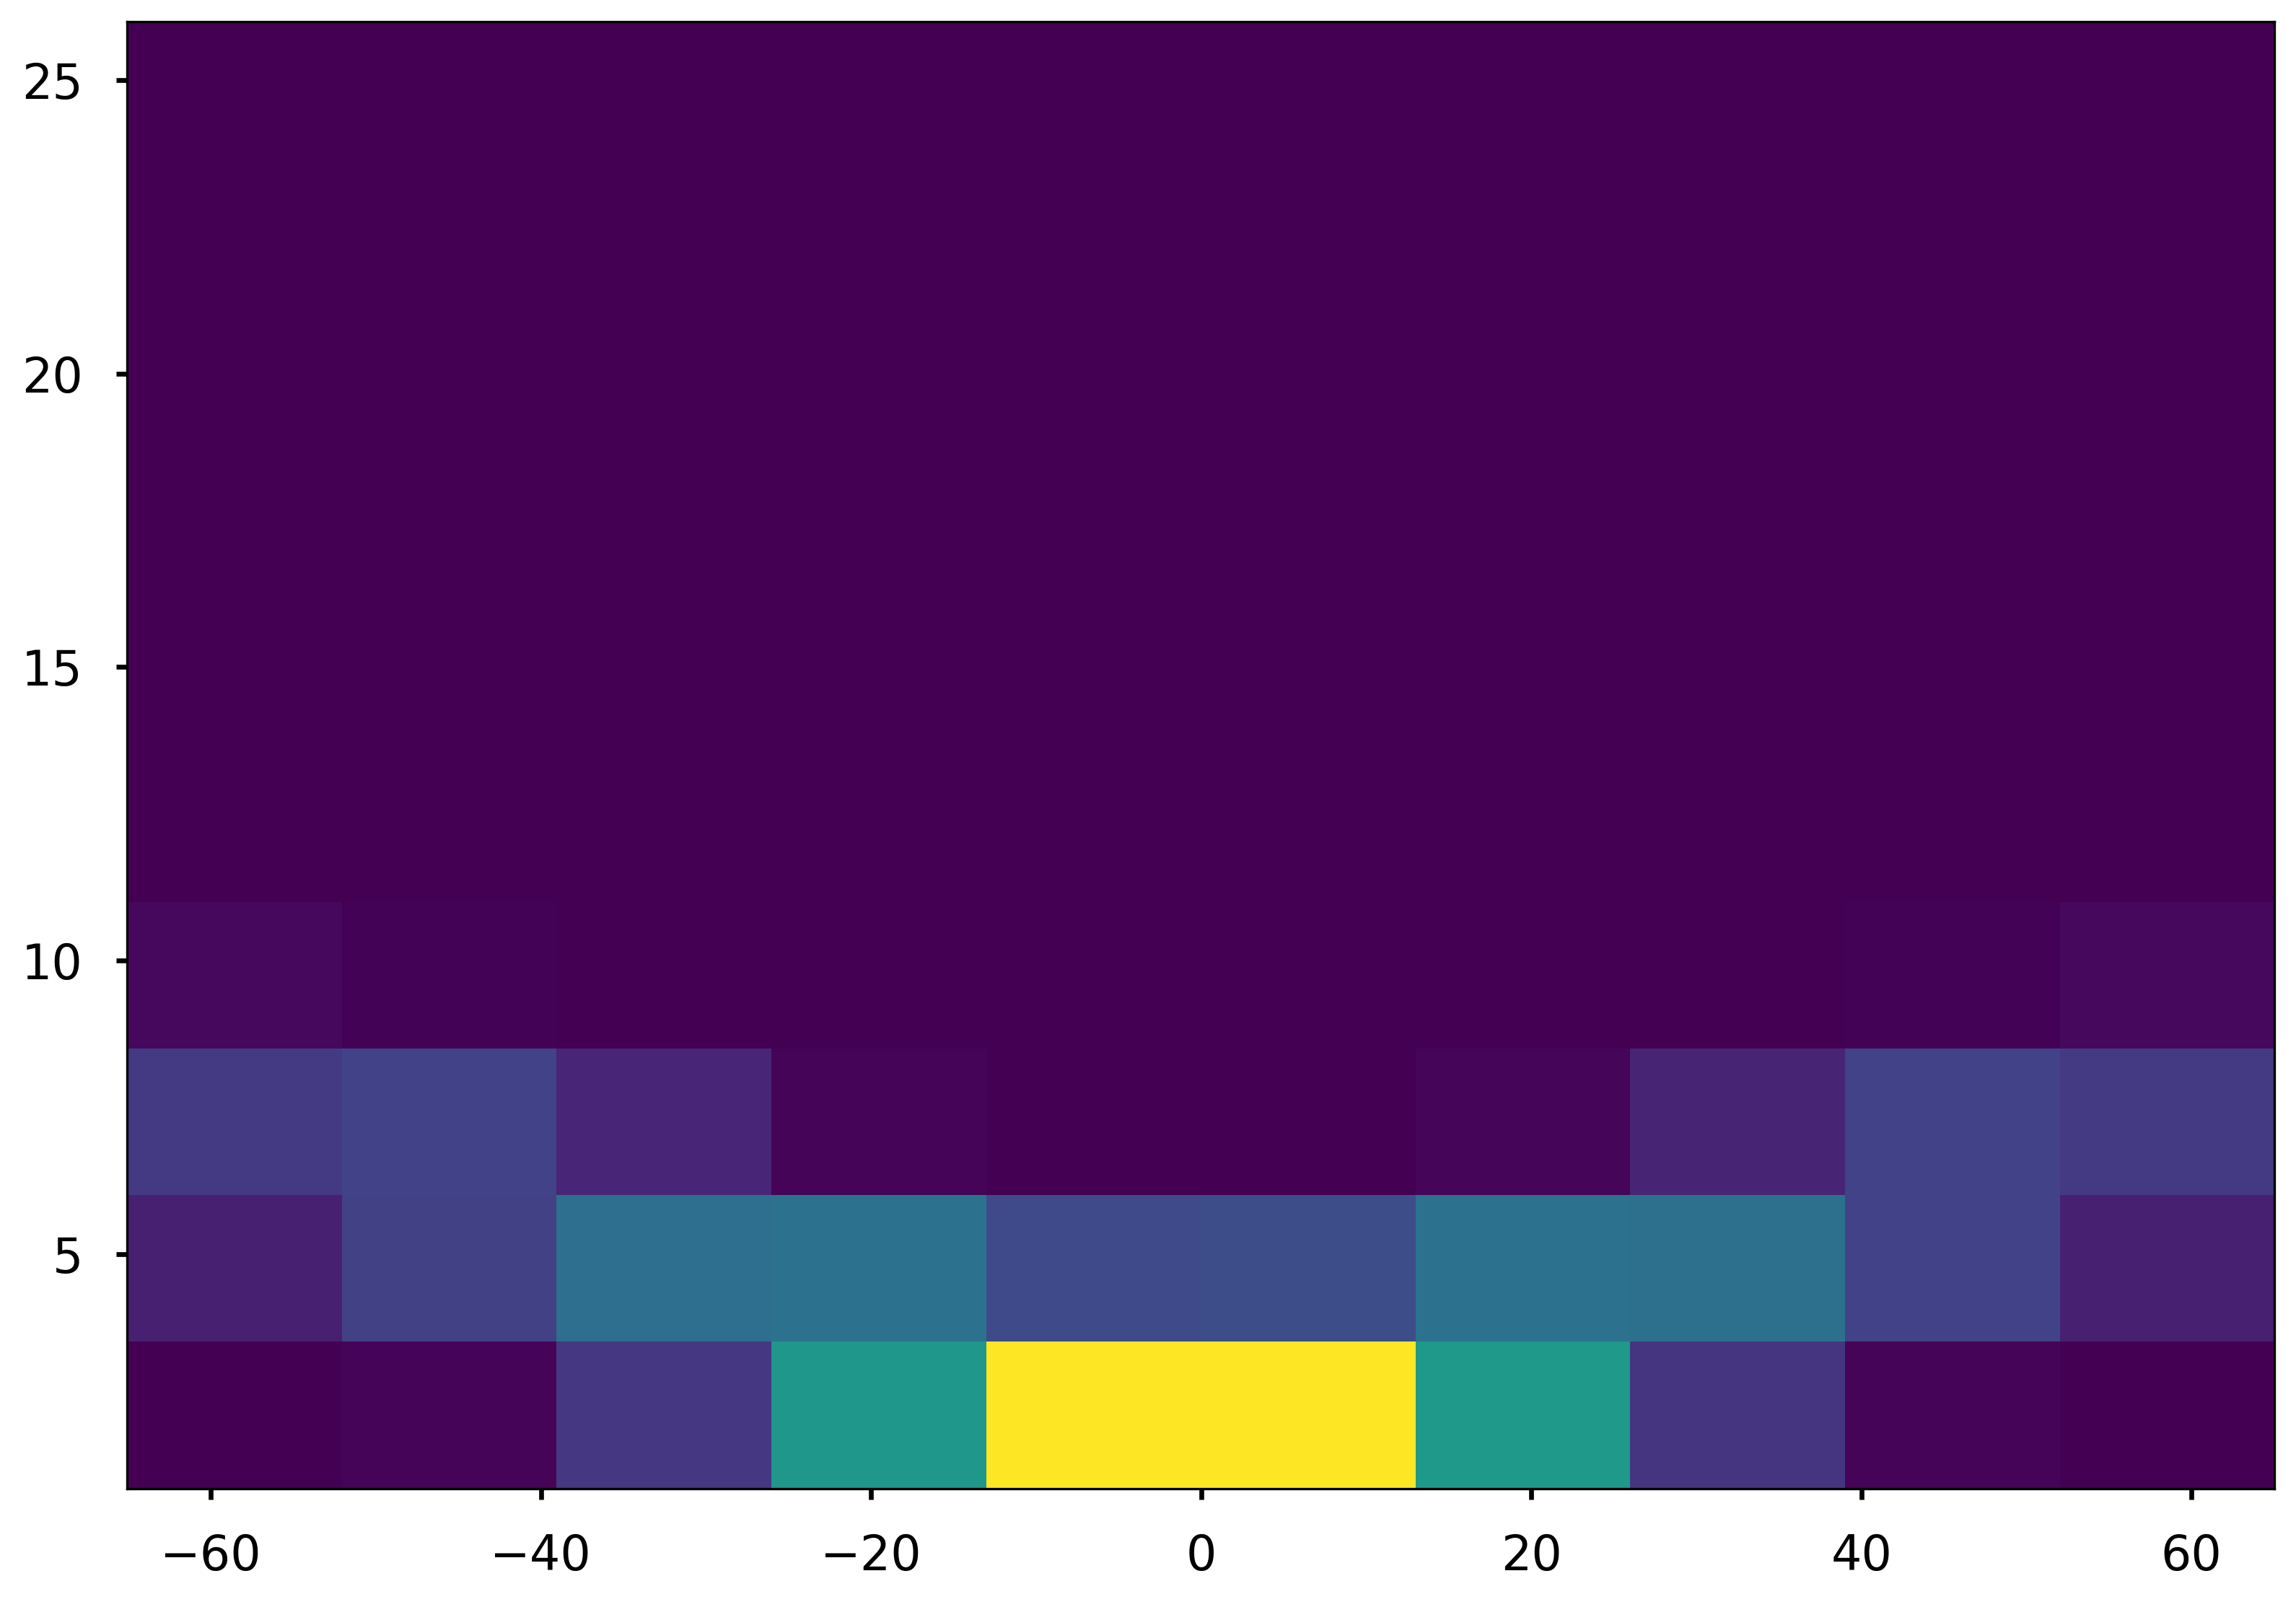

In [33]:
plt.hist2d(bibVarDF["z-global"],bibVarDF["nPix"])
plt.hist2d(sigVarDF["z-global"],sigVarDF["nPix"])

In [5]:
import os
import sys
sys.path.append("/home/dabadjiev/smartpixels_ml_dsabadjiev/Muon_Collider_Smart_Pixels/daniel/validationPlots")
from SpixPlotter import SmartpixPlotter
import argparse
from pathlib import Path
import matplotlib
import plotUtils
import numpy as np
###########################################################################
########## Defaults for data directories, copied from runPlots2.py
repodir = Path("/home/dabadjiev/smartpixels_ml_dsabadjiev/Muon_Collider_Smart_Pixels")
print("Assuming you are starting in .....paperPlots, so git repo dir is ", repodir)
assert repodir.parts[-1] == 'Muon_Collider_Smart_Pixels'
dataDir_all = "Data_Set_2026Feb"
if dataDir_all is not None:
    print("Using a dataset directory with subfolders, following Eliza's 2026 dataset format, ignoring other directories")
    print("Setting plot directory inside dataset folder")
    #either dataDir_all is a string witht the dataset name, in which case join paths from DataFiles and repodir
    #otherwise, dataDir_all should be an absolute path to the dataset
    # if 
    datasetPath = Path(dataDir_all)
    if len(datasetPath.parts) == 1:
        print("looking for the dataset in Data_Files")
        datasetDir = repodir.joinpath("Data_Files").joinpath(datasetPath)
    else:
        print("assuming dataset passed is in an absolute path")
        datasetDir = datasetPath
    parquetDir_all = datasetDir.joinpath("Parquet_Files")
    trackDirBib_mm = datasetDir.joinpath("Track_Lists")
    trackDirBib_mp = datasetDir.joinpath("Track_Lists")
    trackDirSig = datasetDir.joinpath("Track_Lists")
    # PLOT_DIR = datasetDir.joinpath("plots")
###########################################################################

STYLESHEET = "seaborn-v0_8-colorblind"
STYLESHEET = "seaborn-v0_8-poster"

matplotlib.rcParams["figure.dpi"] = 300
matplotlib.pyplot.rcParams["patch.linewidth"] = 2


def main(parquetDir_all = "/local/d1/smartpixML/bigData/allData/",     #this should be not used?          
            #skip_indices = list(range(1730 - 124+87, 1769)),
            trackDirBib_mm = trackDirBib_mm,
            trackDirBib_mp = trackDirBib_mp,
            trackDirSig = trackDirSig,
            processRecon = False,
            interactivePlots = False,
            PLOT_DIR = "../datasetPlots",
            savedPklFromParquet = True,
            processTracks = True,
            processOldTracks = False,
            plotTracklists = True,
            plotParquets = True,
            styleSheet=STYLESHEET,):
    plotter = SmartpixPlotter(
                    #  parquetDir_mm = parquetDir_mm , #Not yet implemented
                    #  parquetDir_mp = parquetDir_mp ,
                    #  parquetDir_sig = parquetDir_sig ,
                    parquetDir_all = parquetDir_all ,
                    skip_indices = None,#list(range(1730 - 124+87, 1769)),
                    trackDirBib_mm = trackDirBib_mm,
                    trackDirBib_mp = trackDirBib_mp,
                    trackDirSig = trackDirSig,
                    processRecon = processRecon,
                    interactivePlots=interactivePlots,
                    PLOT_DIR = PLOT_DIR,# os.path.join(os.path.dirname(os.path.abspath(__file__)), "plots"),
                    savedPklFromParquet = savedPklFromParquet,
                    processTracks = processTracks,
                    processOldTracks = processOldTracks,
                    plotTracklists = plotTracklists,
                    plotParquets = plotParquets,
                    styleSheet = styleSheet,
                    )
    # plotter.runPlots()
    return plotter

Assuming you are starting in .....paperPlots, so git repo dir is  /home/dabadjiev/smartpixels_ml_dsabadjiev/Muon_Collider_Smart_Pixels
Using a dataset directory with subfolders, following Eliza's 2026 dataset format, ignoring other directories
Setting plot directory inside dataset folder
looking for the dataset in Data_Files


In [6]:
plotter = main()

loading data, Currently loading settings: 
processRecon: False
savedPklFromParquet: True
interactivePlots: False
[    488     489     490 ... 3119334 3119335 3119336]
len truthSig: 1600000
len truthBib: 1600000
len truthBib_mm: 809783
len truthBib_mp: 790217
fraction of total that are MM: 0.2530571875
fraction of total that are MP: 0.2469428125
fraction of total that are Bib: 0.5
fraction of total that are Sig: 0.5
Finished loading parquet data [not counting tracks], now proceeding to plotting or tracklists
Start loading track data
/home/dabadjiev/smartpixels_ml_dsabadjiev/Muon_Collider_Smart_Pixels/Data_Files/Data_Set_2026Feb/Track_Lists
/home/dabadjiev/smartpixels_ml_dsabadjiev/Muon_Collider_Smart_Pixels/Data_Files/Data_Set_2026Feb/Track_Lists
/home/dabadjiev/smartpixels_ml_dsabadjiev/Muon_Collider_Smart_Pixels/Data_Files/Data_Set_2026Feb/Track_Lists
Loaded tracks with counting of 
 bib mm: 875437 
 bib mp: 856000  
 bib total: 1731437 
 Signal: 1750000 
Nan m count: 0
Nan m count: 0

In [7]:
plotter.truthBib

,x-entry,y-entry,z-entry,n_x,n_y,n_z,number_eh_pairs,y-local,z-global,pt,...,scalePion,p_calc1,p_calc2,p_calc3,betaGamma,pathLength,EHperMicron,xSize,ySize,nPix
0,12.612453,14.527484,0.0,-0.007871,-0.018733,0.062323,28409.0,-1.875,5.975000,0.00024,...,273.131115,0.00024,0.000242,0.000242,0.469669,52.590350,540.194160,2,1,2
1,29.066113,65.269089,0.0,0.036481,-0.130226,0.110756,5391.0,-2.350,4.775000,0.00063,...,273.131115,0.00064,0.000644,0.000644,1.252449,78.914174,68.314724,2,3,5
2,-44.518486,14.245097,0.0,0.057630,-0.088582,0.082119,9590.0,-2.450,4.750000,0.00044,...,273.131115,0.00049,0.000488,0.000488,0.958902,81.487791,117.686341,3,2,6
3,6.897231,23.592140,0.0,-0.093445,-0.085867,0.153784,6196.0,-3.250,5.975000,0.00064,...,273.131115,0.00073,0.000724,0.000724,1.428571,64.826519,95.578169,2,1,2
4,6.639468,-42.642422,0.0,-0.017276,0.102190,0.140767,7664.0,-3.100,6.025000,0.00064,...,273.131115,0.00064,0.000643,0.000643,1.252450,62.090005,123.433715,1,3,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
462,-68.585068,-30.455032,0.0,0.575477,0.175158,0.449792,12871.0,-2.925,60.574998,0.00177,...,273.131115,0.00275,0.002754,0.002754,5.381604,83.495313,154.152366,3,2,6
463,-10.565133,62.961945,0.0,5.269325,-3.755303,3.062653,7275.0,1.800,-36.250002,0.01774,...,273.131115,0.02621,0.026207,0.026207,51.291581,116.871973,62.247602,3,2,8
464,29.091125,-40.341335,0.0,-4.269450,3.197529,2.917666,10542.0,-0.800,-19.324999,0.01585,...,273.131115,0.02226,0.022263,0.022263,43.561645,104.191138,101.179430,3,2,8
465,-43.689495,43.477692,0.0,4.254432,-3.025033,3.041487,8250.0,4.475,26.475000,0.01571,...,273.131115,0.02212,0.022126,0.022126,43.287672,99.320831,83.064146,3,2,6


In [25]:
# plt.hist2d(plotter.truthBib["z-global"],plotter.truthBib["xSize"])
# plt.hist2d(plotter.truthBib["eta"],plotter.truthBib["nPix"])
# plt.hist2d(plotter.truthSig["z-global"],plotter.truthSig["xSize"])
print(plotter.truthBib.keys())

Index(['x-entry', 'y-entry', 'z-entry', 'n_x', 'n_y', 'n_z', 'number_eh_pairs',
       'y-local', 'z-global', 'pt', 'hit_time', 'PID', 'cotAlpha', 'cotBeta',
       'y-midplane', 'x-midplane', 'adjusted_hit_time',
       'adjusted_hit_time_30ps_gaussian', 'adjusted_hit_time_60ps_gaussian',
       'source', 'eta', 'R', 'q', 'm', 'scalePion', 'p_calc1', 'p_calc2',
       'p_calc3', 'betaGamma', 'pathLength', 'EHperMicron', 'xSize', 'ySize',
       'nPix'],
      dtype='object')


In [129]:
def plotHaha(truthBib = plotter.truthBib,truthSig = plotter.truthSig,cut=None,plotZgXs=False,plotEtXs=False,plotNpEt=True):
    # mask_bib,mask_sig,mask_bib_x,mask_sig_x,mask_bib_y,mask_sig_y, = plotUtils.getEricsMasks(plotter.truthBib, plotter.truthSig, plotter.xSizesSig, plotter.xSizesBib, plotter.ySizesSig, plotter.ySizesBib,)
    
    if cut is not None:
        truthBib = truthBib.query(cut); truthSig = truthSig.query(cut)
    
    mask_bib = [True for _ in truthBib["z-global"]]
    mask_sig = [True for _ in truthSig["z-global"]]
    if plotZgXs:
        plotUtils.plot1by2BibSig2dHisto(truthBib,truthSig,'z-global', 'xSize',mask_bib,mask_sig,30,np.arange(0,22,1),"Blues",
                                r'$z_{\mathrm{global}}$ [mm]',r'$x_{\mathrm{size}}$ [# pixels]', "bib_signal_zglobal_vs_xsize_comparison",
                                plotter.PLOT_DIR,True,logColor=True,colorLabel=r"$n_{\mathrm{clusters}}$")
    if plotEtXs:
        plotUtils.plot1by2BibSig2dHisto(truthBib,truthSig,'eta', 'xSize',mask_bib,mask_sig,30,np.arange(0,22,1),"Blues",
                                r'$\eta$ ',r'$x_{\mathrm{size}}$ [# pixels]', "bib_signal_zglobal_vs_xsize_comparison",
                                plotter.PLOT_DIR,True,logColor=True,colorLabel=r"$n_{\mathrm{clusters}}$")
    if plotNpEt:
        plotUtils.plot1by2BibSig2dHisto(truthBib,truthSig,'eta', 'nPix',mask_bib,mask_sig,30,np.arange(0,22,1),"Blues",
                                r'$\eta$ ',r'$n_{\mathrm{pix}}$ [# pixels]', "bib_signal_zglobal_vs_xsize_comparison",
                                "./haha",True,logColor=True,colorLabel=r"$n_{\mathrm{clusters}}$")
    print("cut: ",cut)
    numBib=len(truthBib);numSig=len(truthSig)
    print("number BIB clusters ",numBib,"number of signal clusters ",numSig)
    fracBib=len(truthBib)/len(plotter.truthBib);fracSig=len(truthSig)/len(plotter.truthSig)
    print("fraction of total bib ",fracBib," fraction of total signal ",fracSig,)
    return numBib, numSig,fracBib,fracSig
    # plotUtils.plot1by2BibSig2dHisto(plotter.truthBib,plotter.truthSig,'z-global', 'xSize',mask_bib,mask_sig,30,np.arange(0,22,1),pastel_red_cmap,
    #                         r'$z_{\mathrm{global}}$ [mm]',r'$x_{\mathrm{size}}$ [# pixels]', "bib_signal_zglobal_vs_xsize_comparison",
    #                         PLOT_DIR,interactivePlots,logColor=True,colorLabel=r"$n_{\mathrm{clusters}}$")

In [44]:
print(np.max(plotter.truthSig["eta"]))

1.5164780151171064


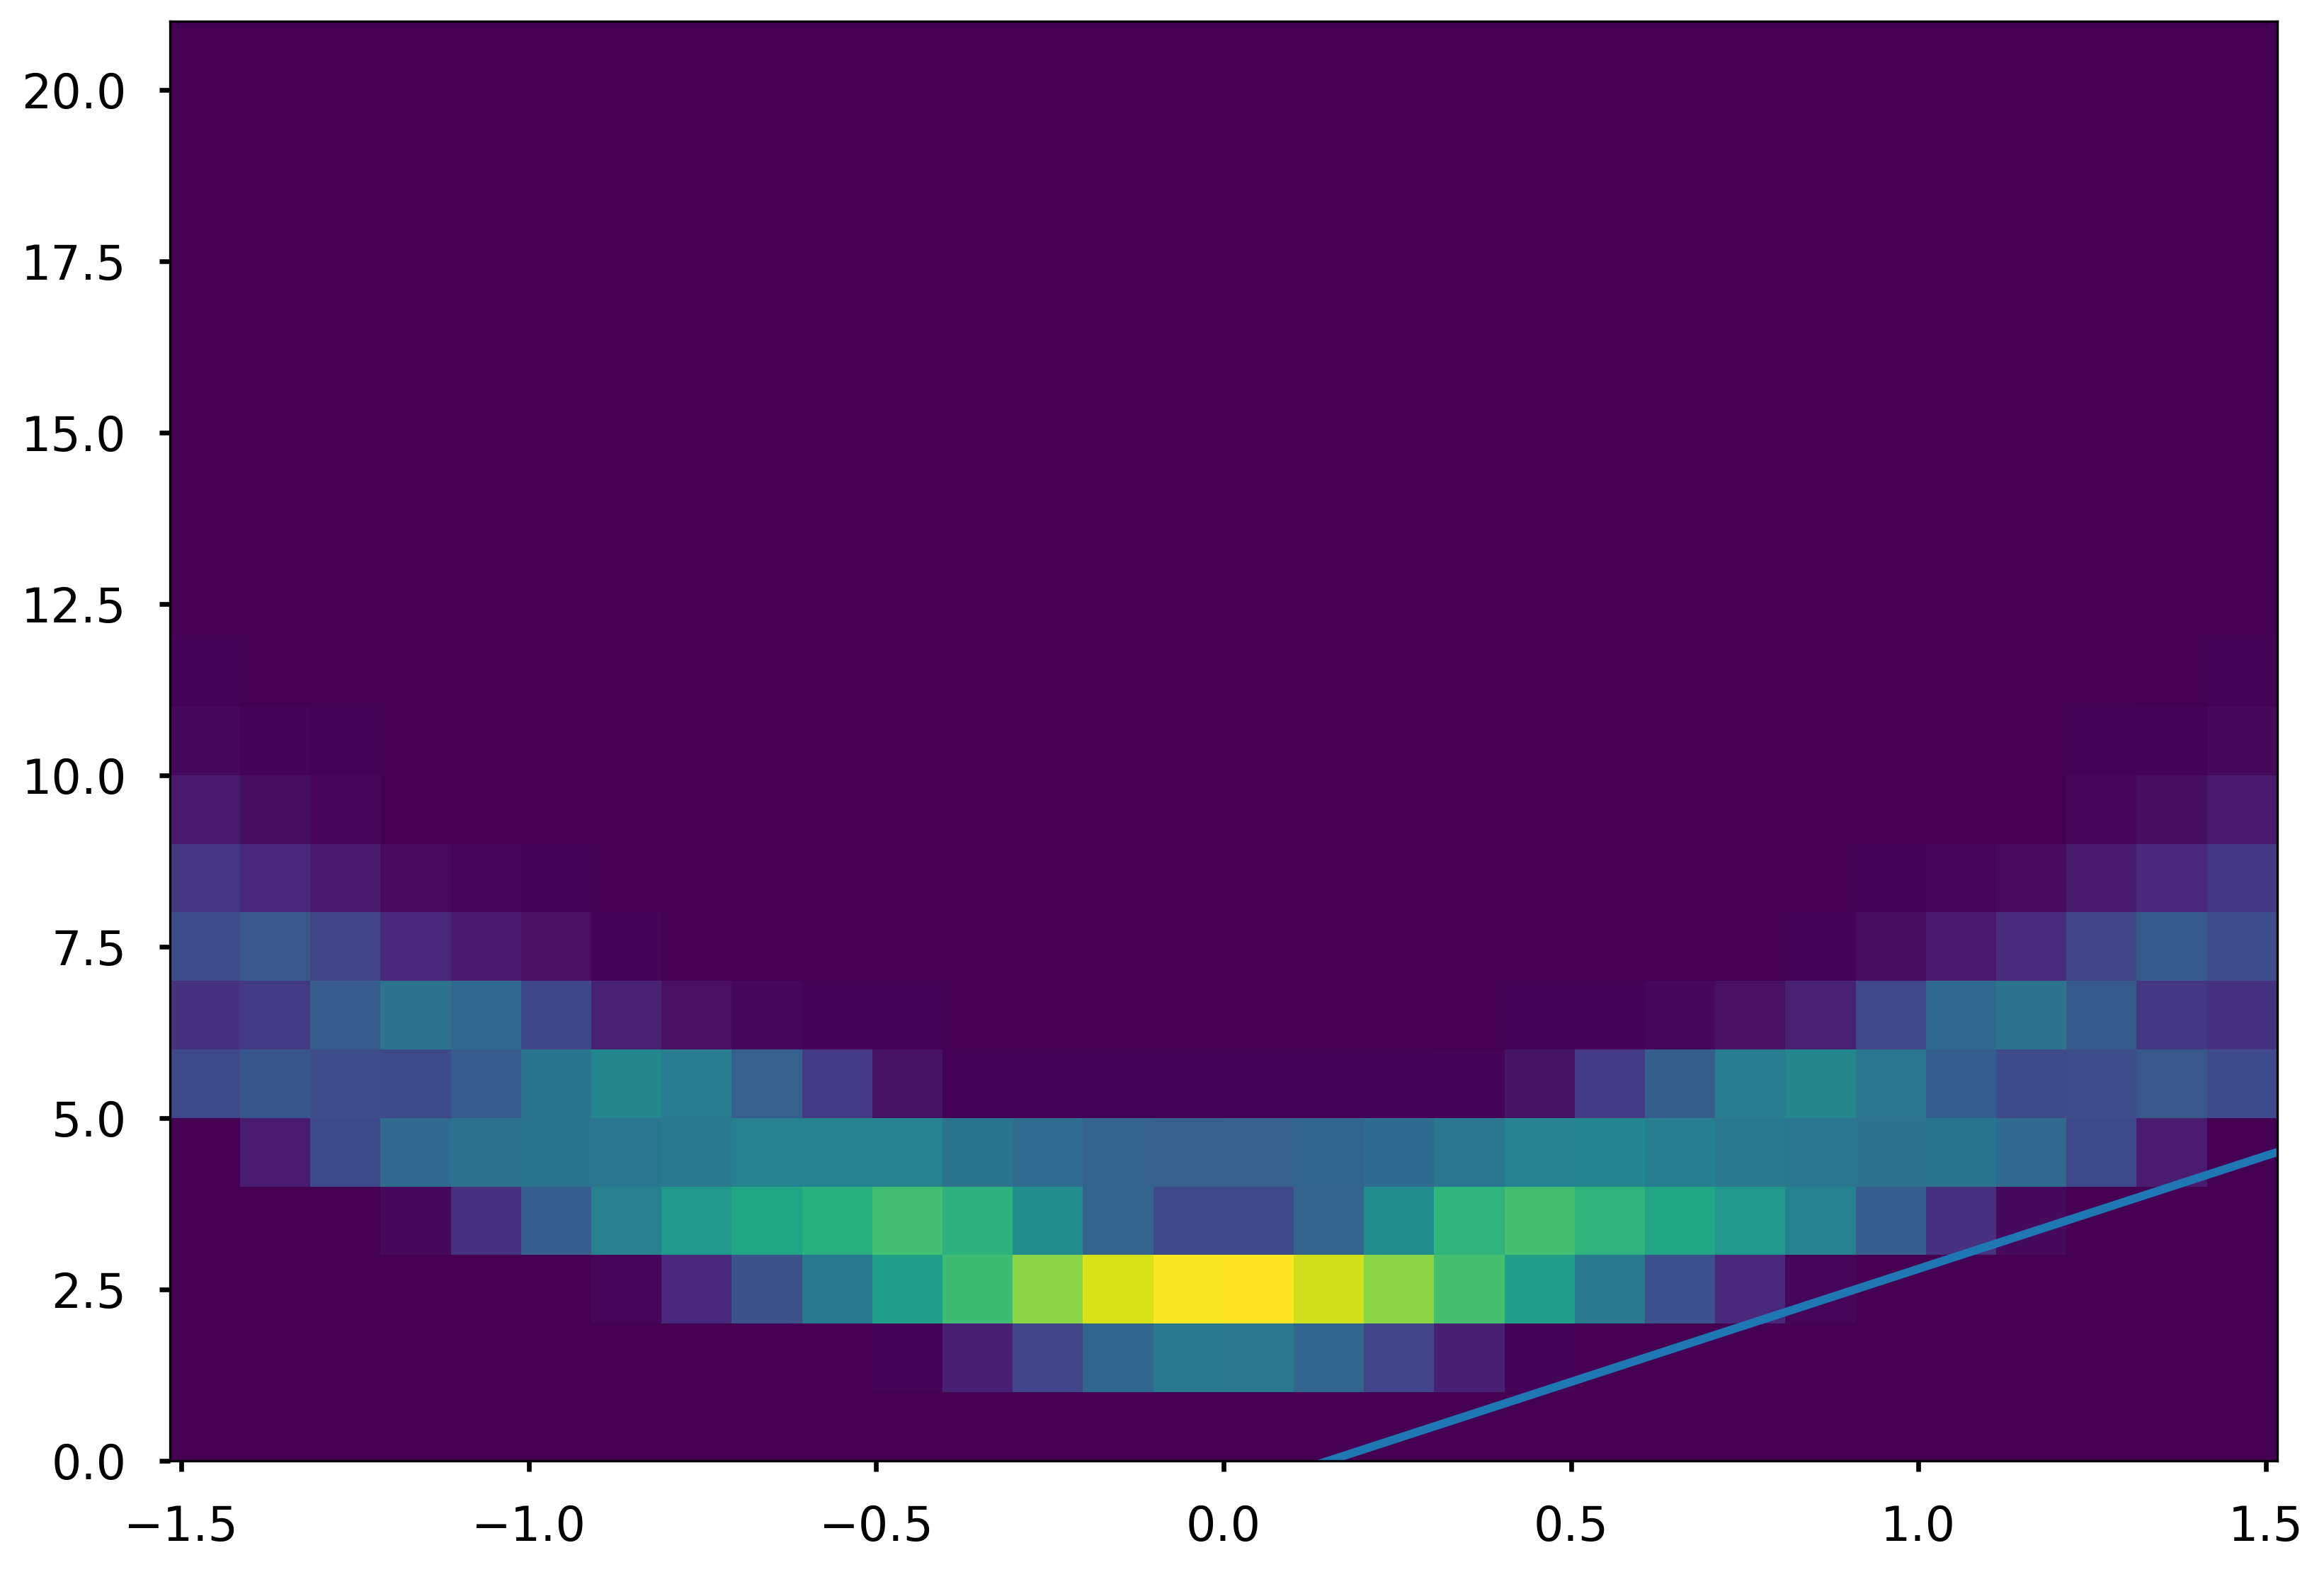

In [100]:
# plotter.truthBib.query("nPix<10")
plt.hist2d(plotter.truthSig["eta"],plotter.truthSig["nPix"],bins=(30,np.arange(0,22,1)))
sampleEtas = np.linspace(0,1.6,10)
plt.plot(sampleEtas,sampleEtas*5/1.516-0.5)
plt.show()

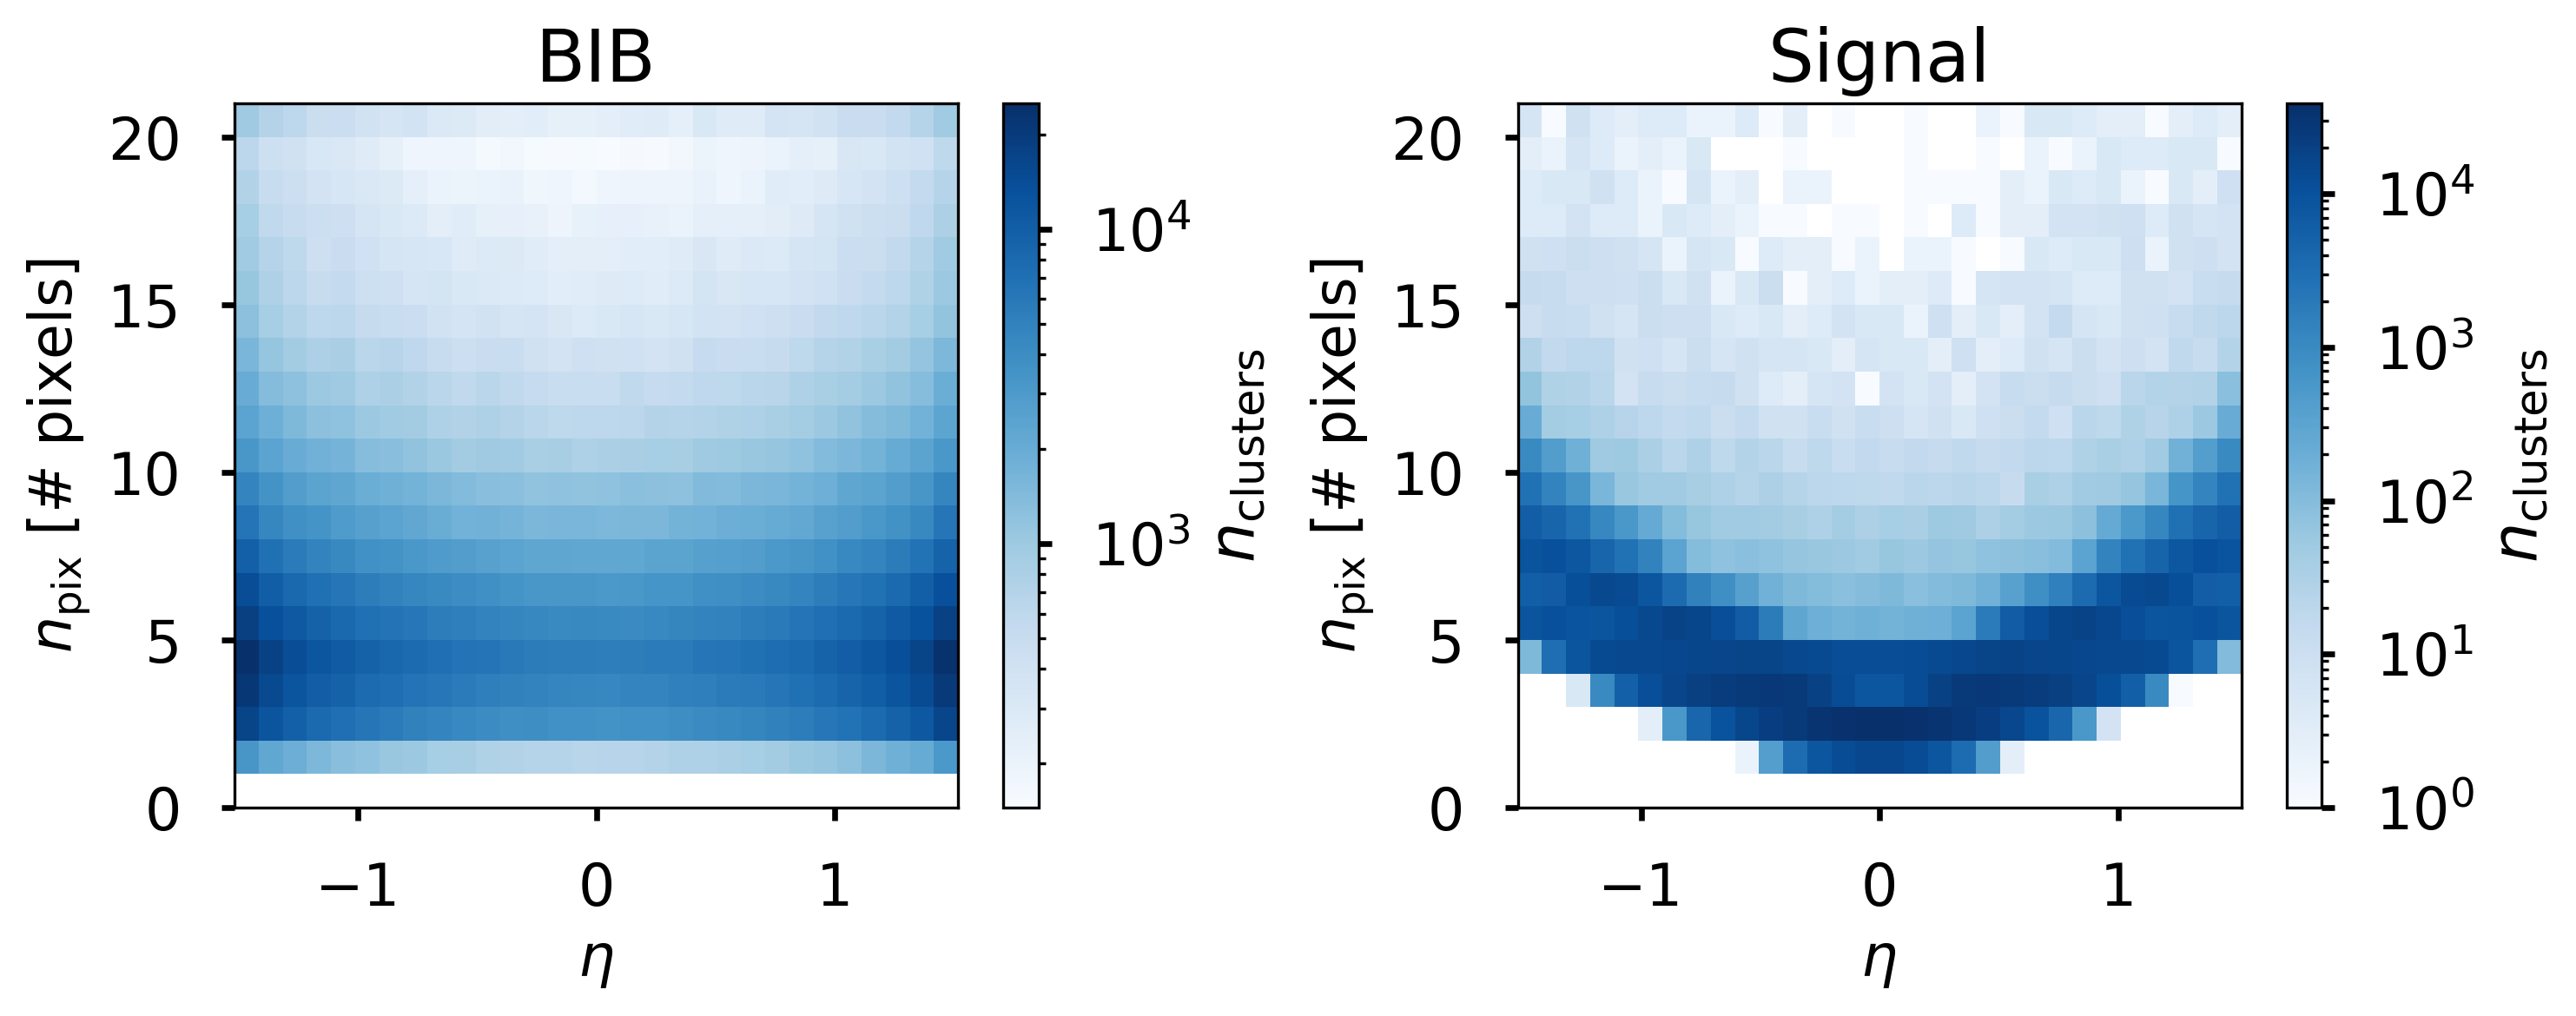

Plot saved as: ./haha/bib_signal_zglobal_vs_xsize_comparison.png
cut:  None
number BIB clusters  1656656 number of signal clusters  1717087
fraction of total bib  1.0  fraction of total signal  1.0


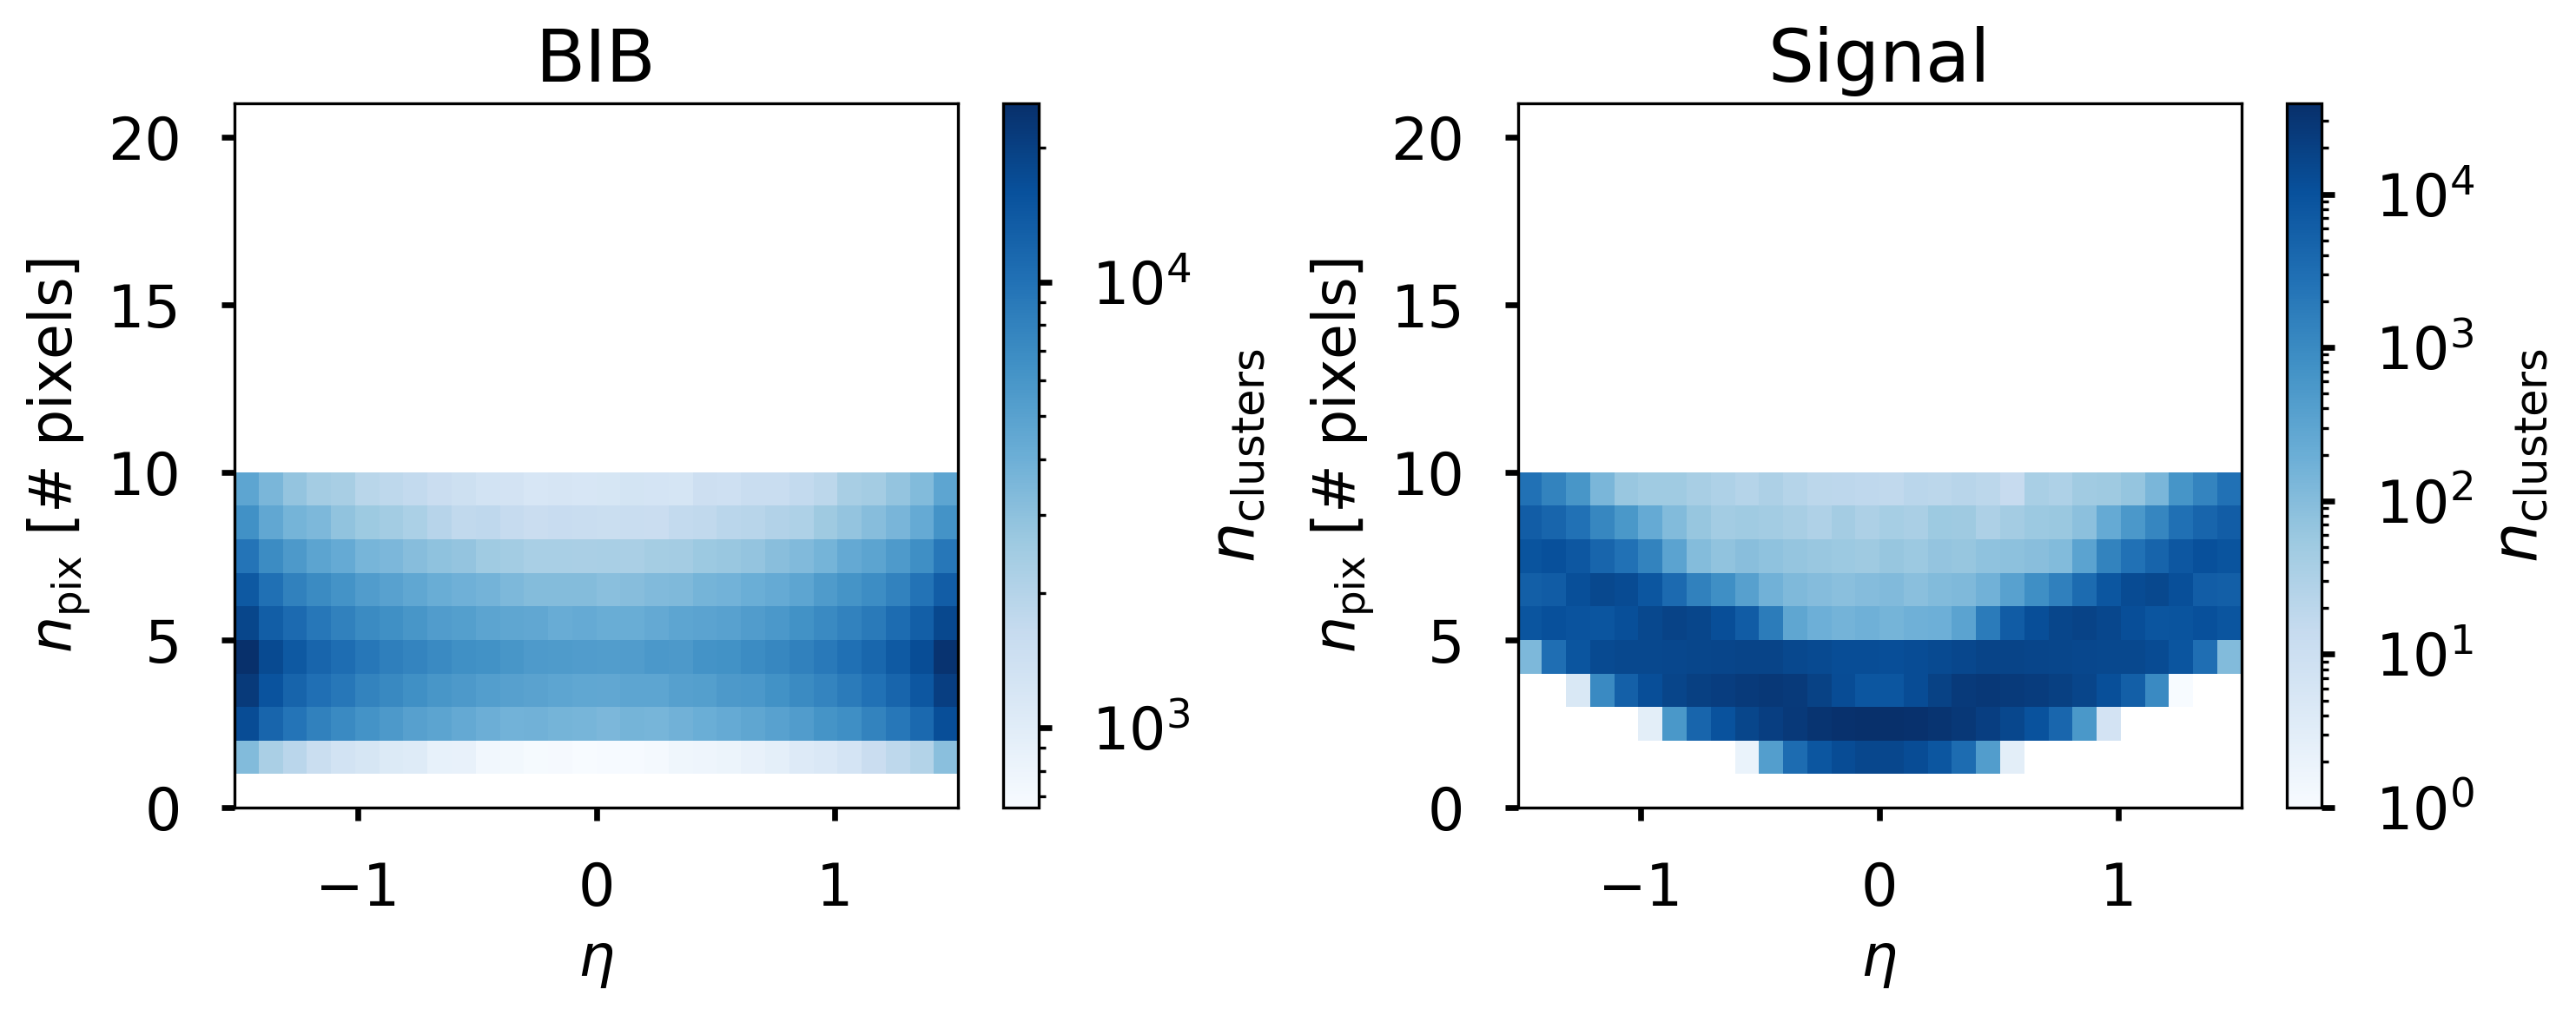

Plot saved as: ./haha/bib_signal_zglobal_vs_xsize_comparison.png
cut:  nPix < 10
number BIB clusters  1424631 number of signal clusters  1710524
fraction of total bib  0.8599437662375291  fraction of total signal  0.9961778290791323


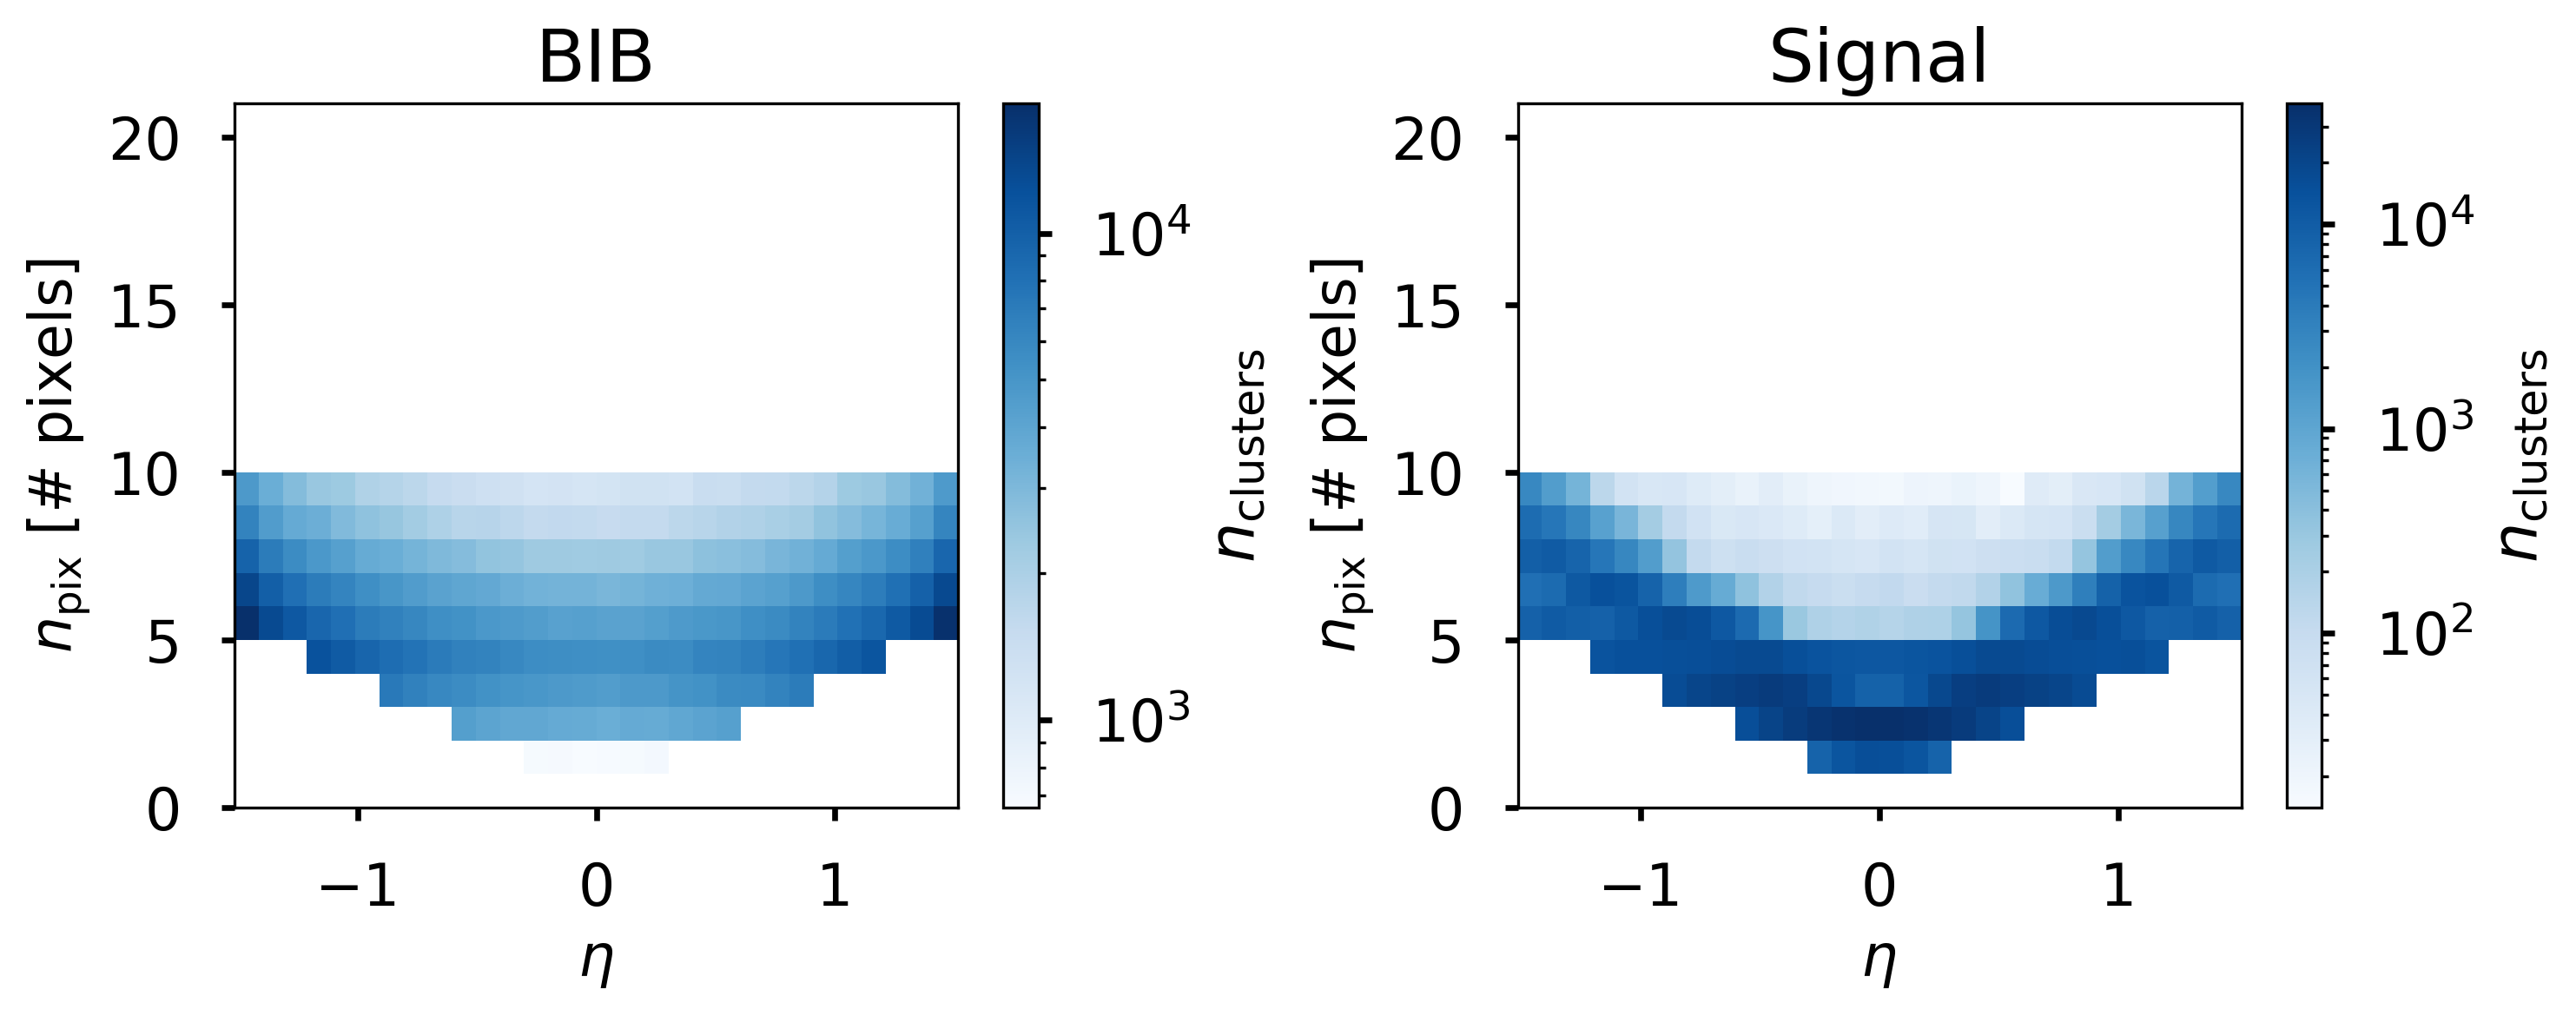

Plot saved as: ./haha/bib_signal_zglobal_vs_xsize_comparison.png
cut:  (nPix < 10) and (nPix>(5/1.516)*eta) and (nPix>(-5/1.516)*eta)
number BIB clusters  980931 number of signal clusters  1614009
fraction of total bib  0.5921150800166117  fraction of total signal  0.9399692618952913


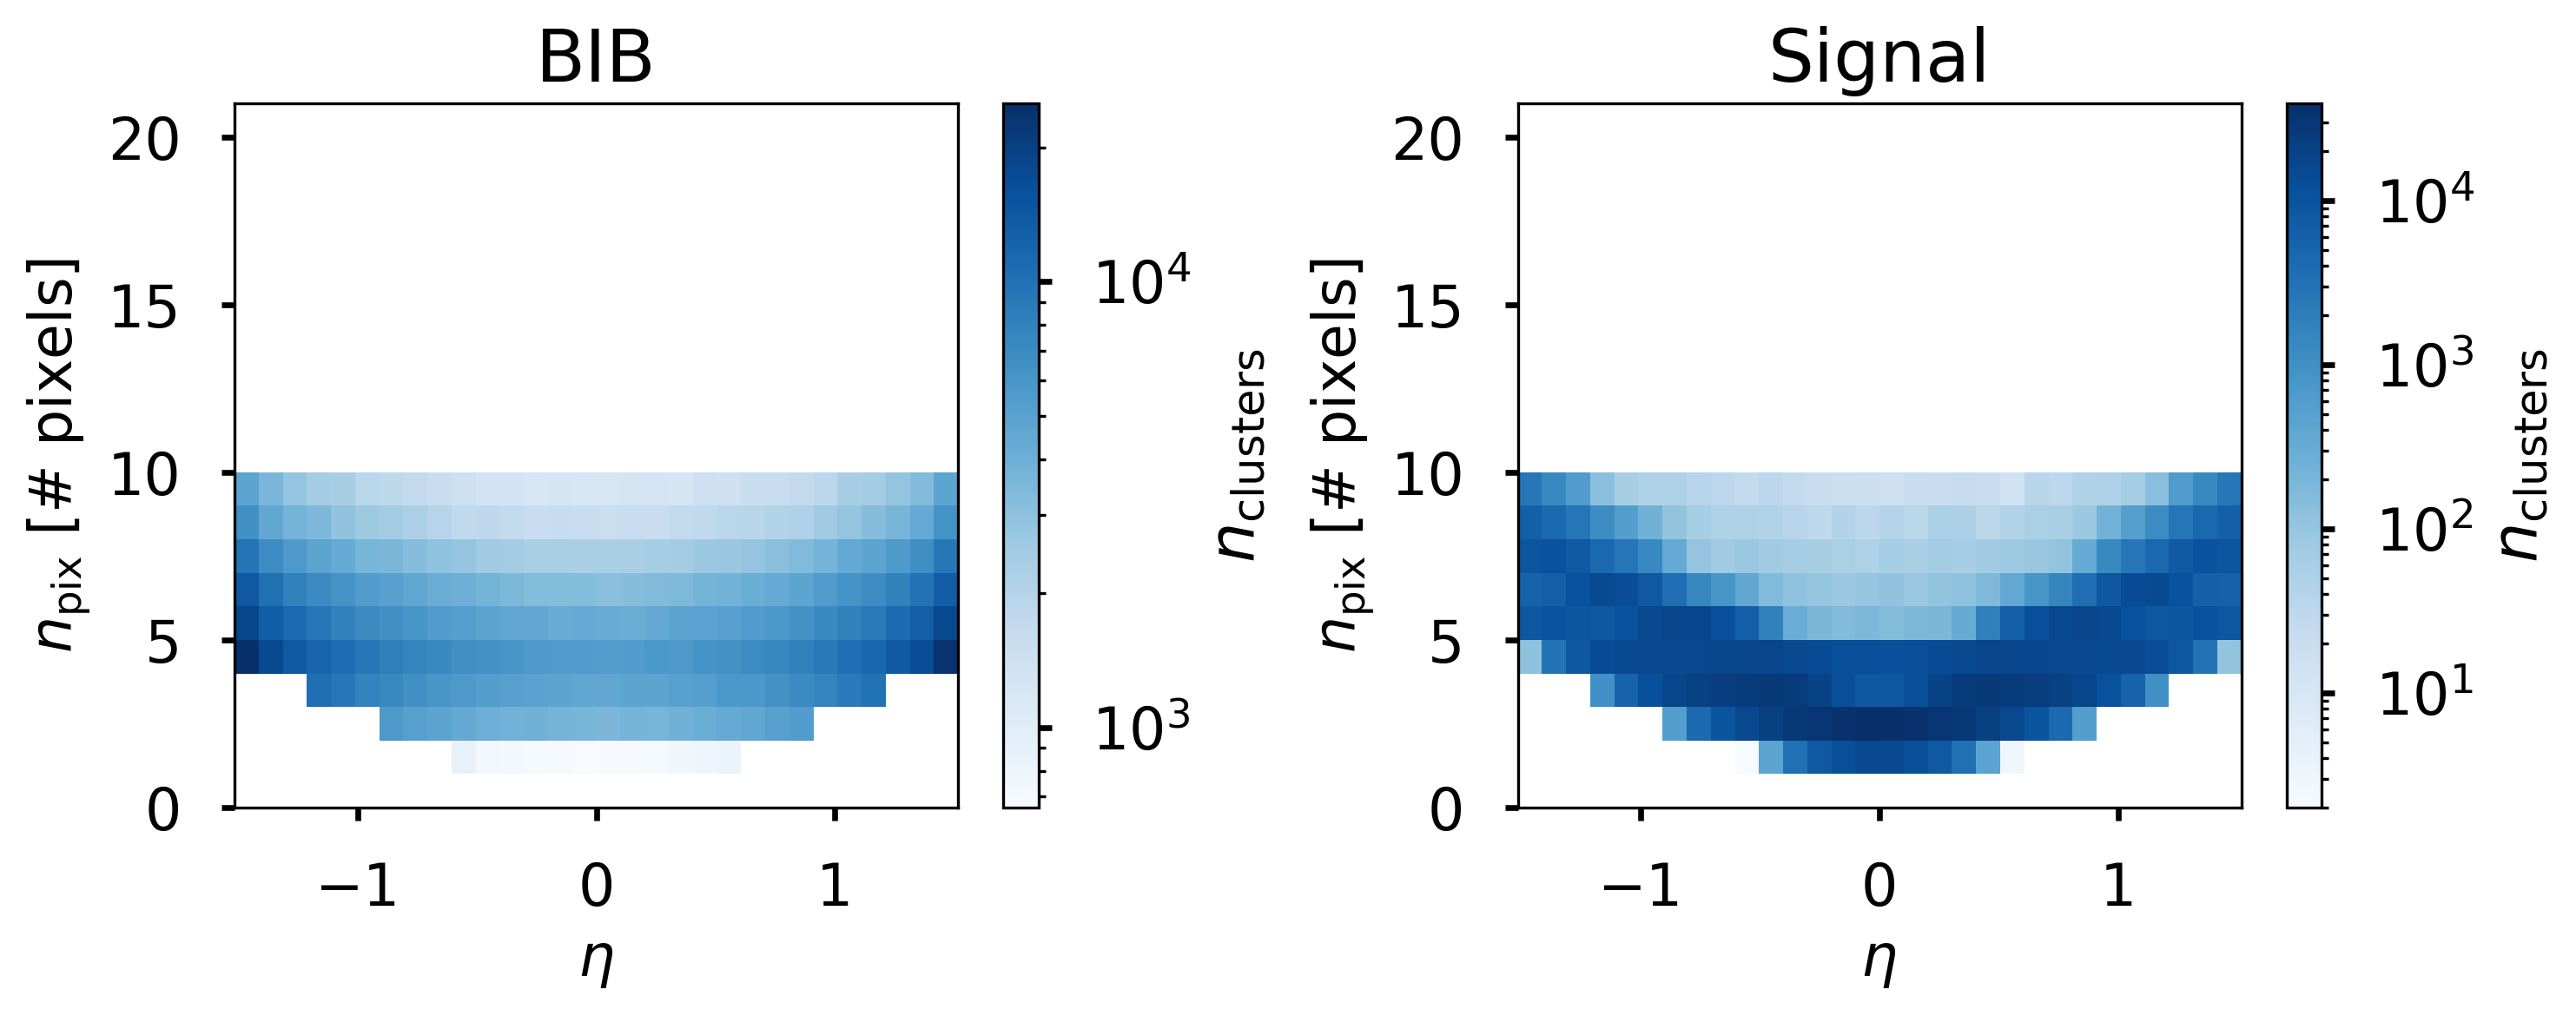

Plot saved as: ./haha/bib_signal_zglobal_vs_xsize_comparison.png
cut:  (nPix < 10) and (nPix> (5/1.516)*eta - 1) and (nPix> (-5/1.516)*eta - 1)
number BIB clusters  1182064 number of signal clusters  1710507
fraction of total bib  0.7135241112216417  fraction of total signal  0.9961679285906888


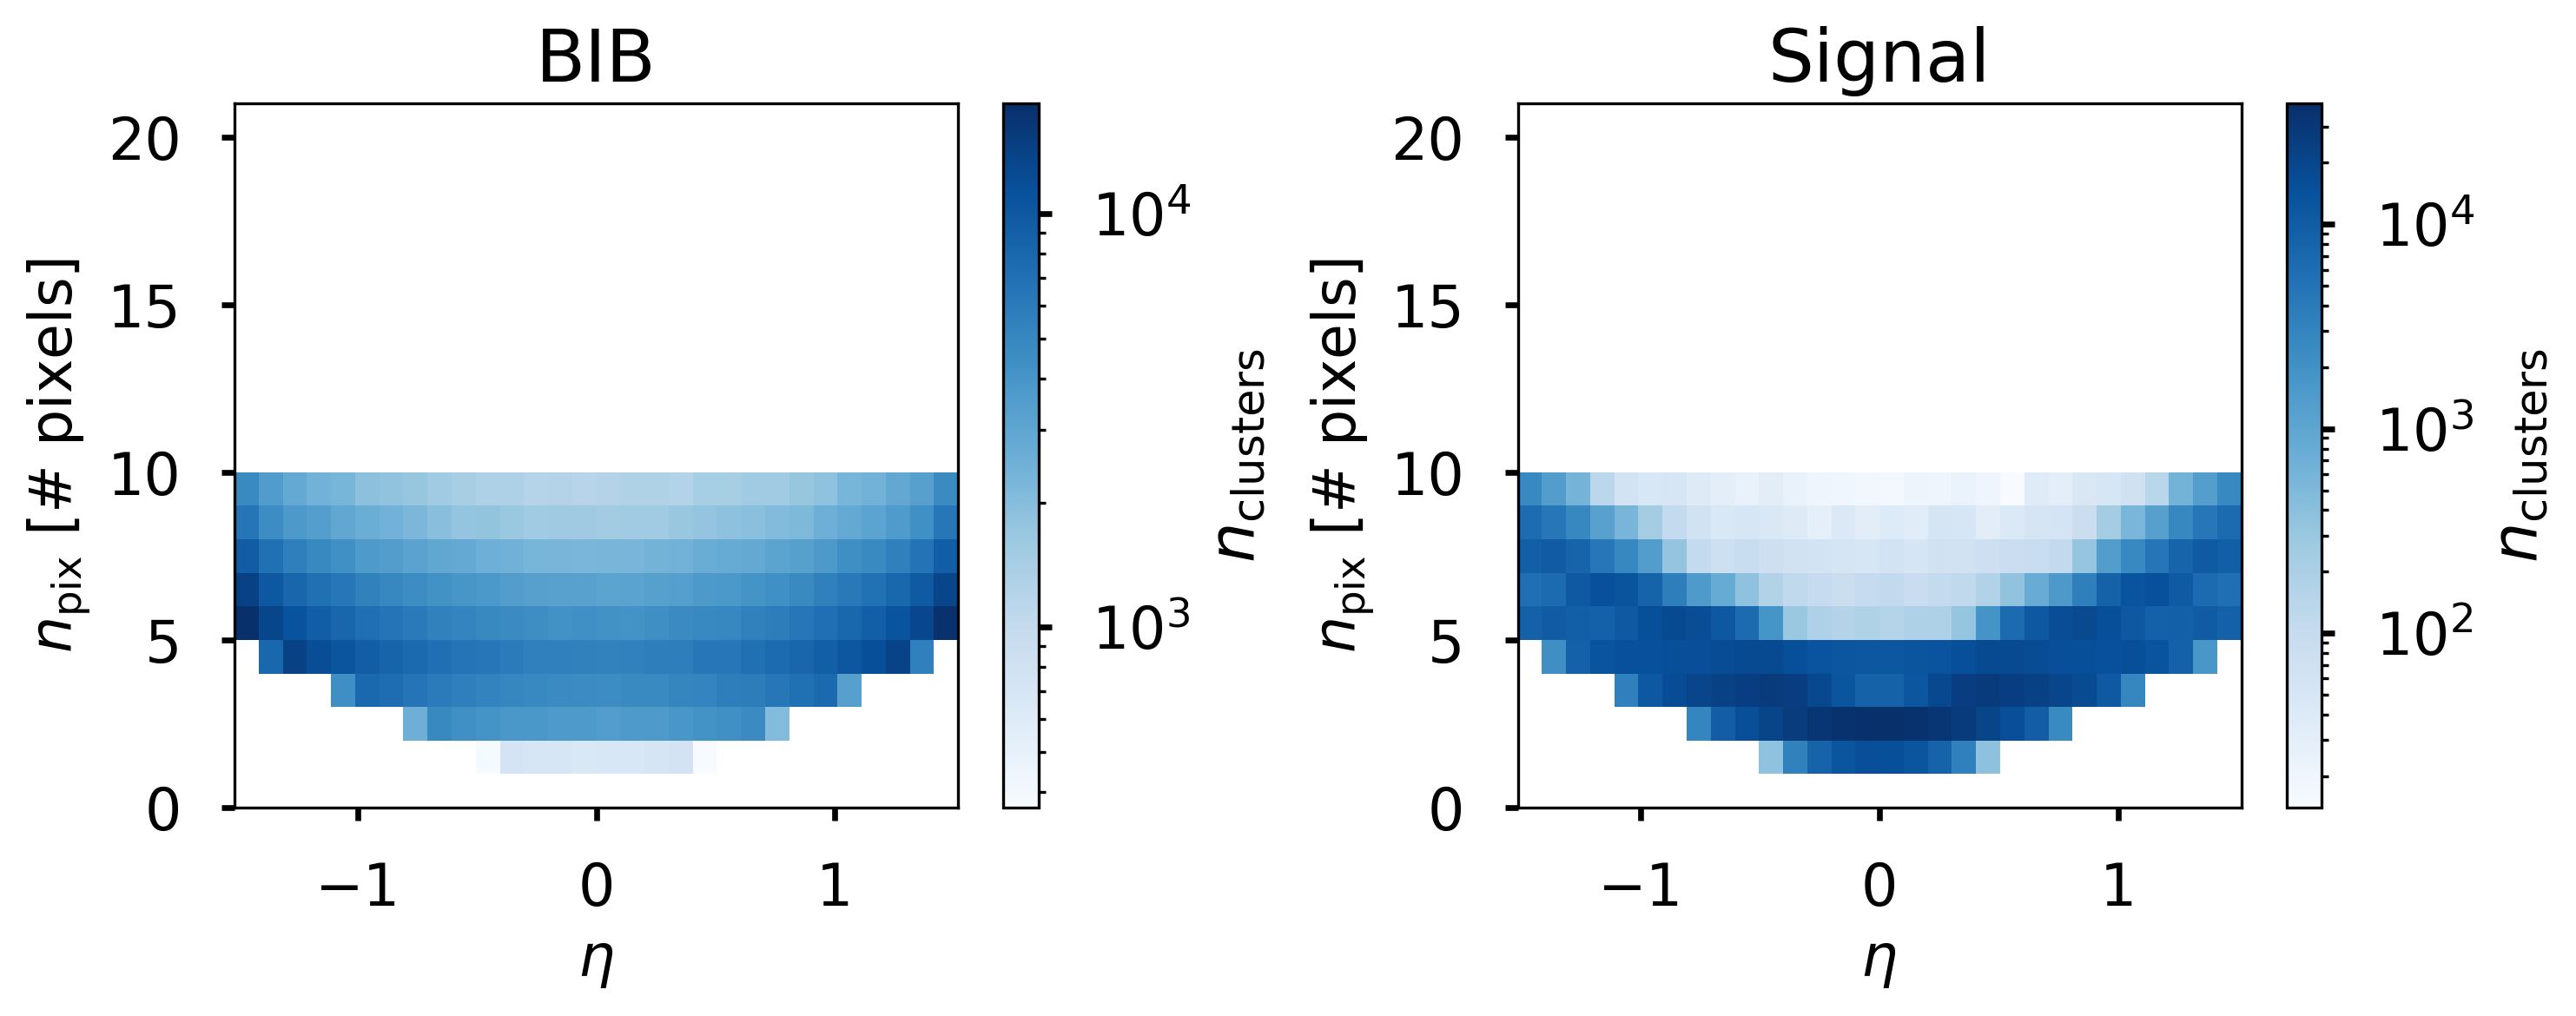

Plot saved as: ./haha/bib_signal_zglobal_vs_xsize_comparison.png
cut:  (nPix < 10) and (nPix> (5/1.5)*eta - 0.5) and (nPix> (-5/1.516)*eta - 0.5)
number BIB clusters  1062493 number of signal clusters  1696475
fraction of total bib  0.6413479925826484  fraction of total signal  0.9879959489530816


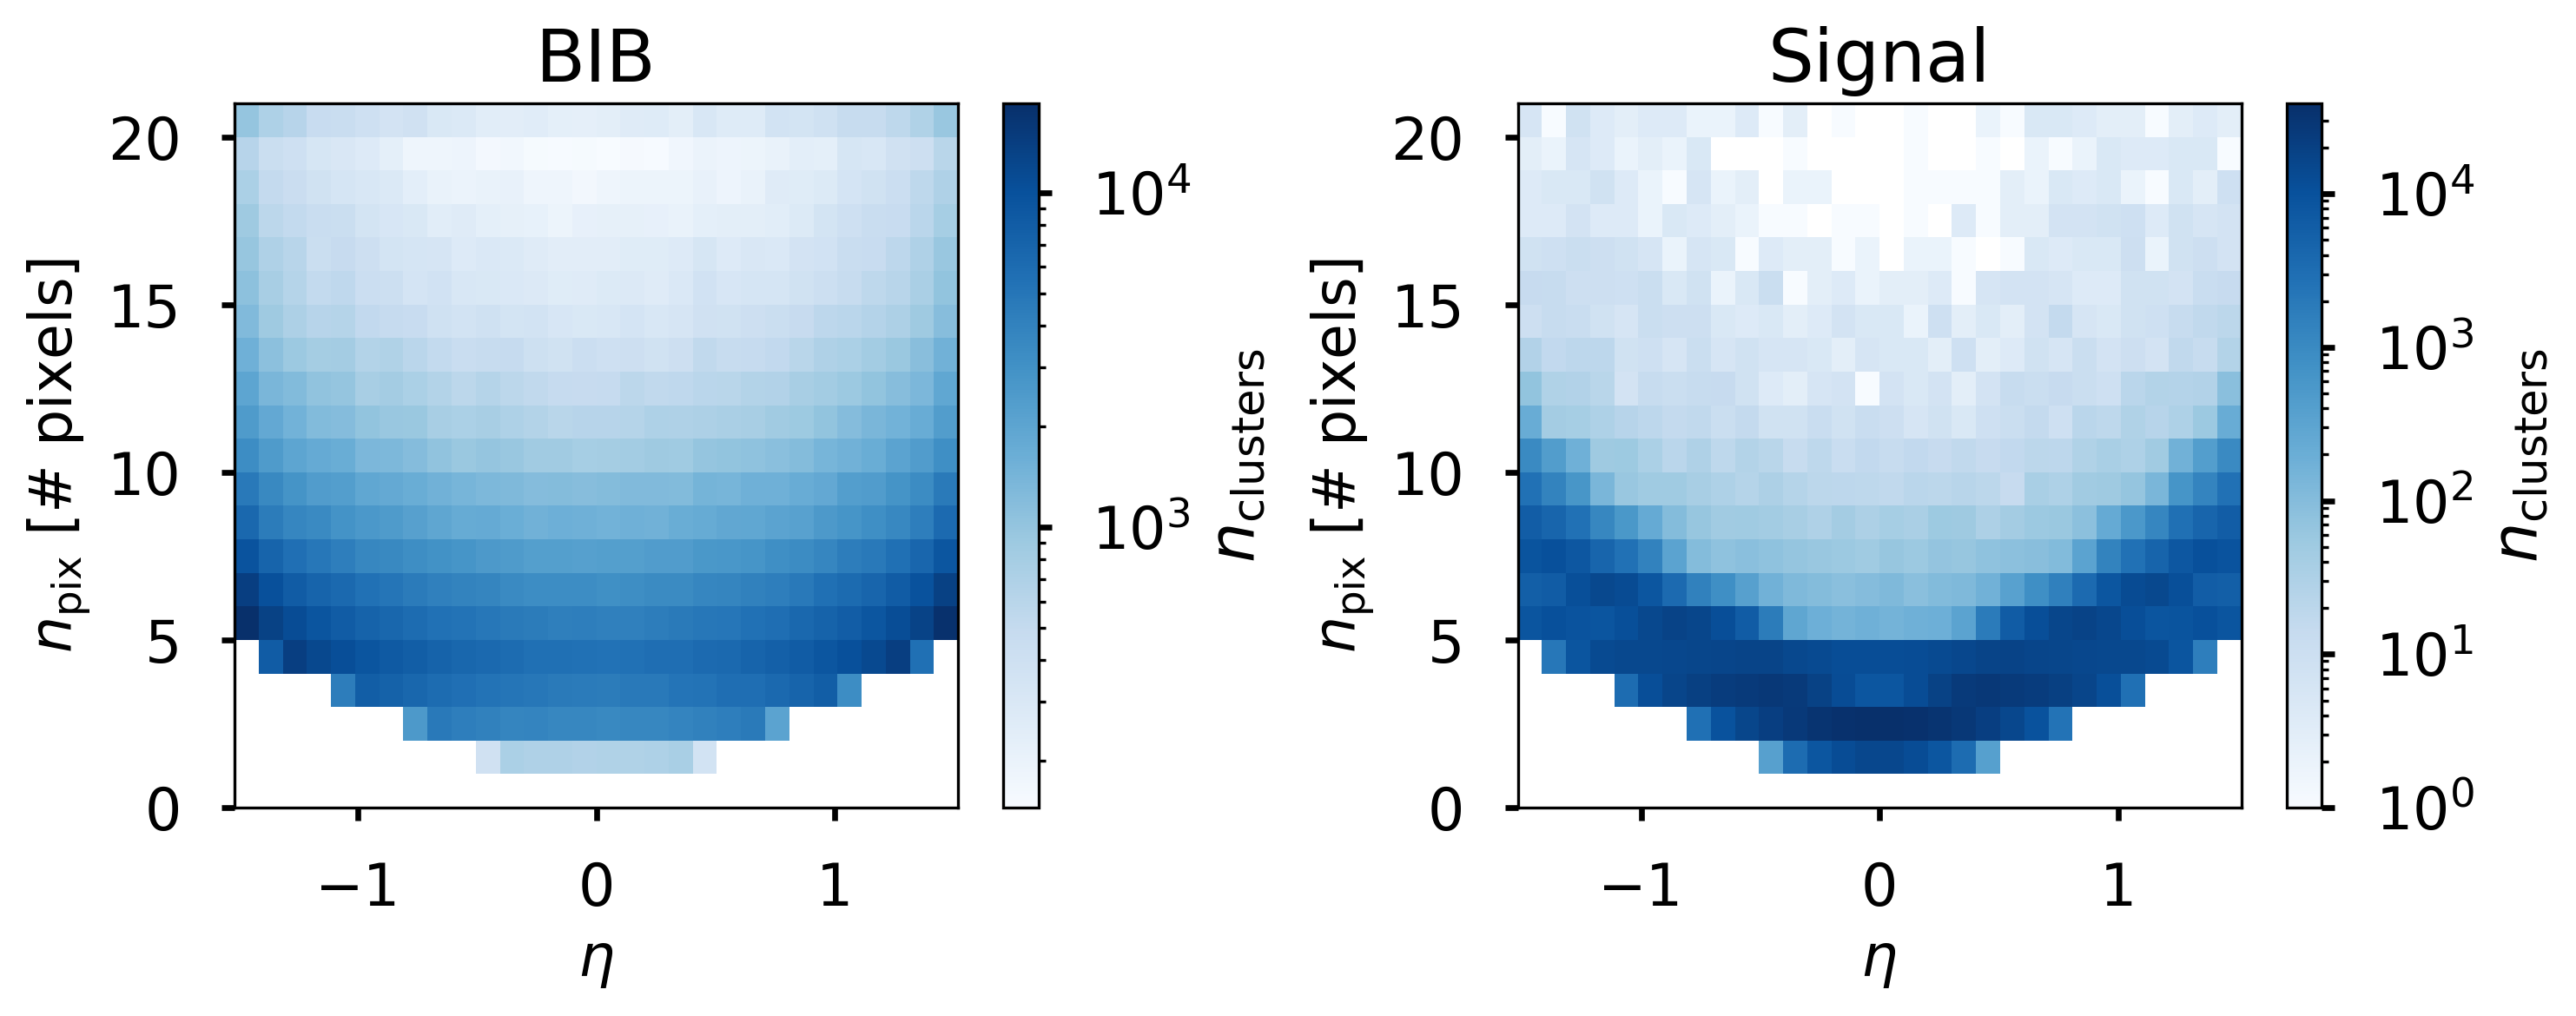

Plot saved as: ./haha/bib_signal_zglobal_vs_xsize_comparison.png
cut:  (nPix> (5/1.5)*eta - 0.5) and (nPix> (-5/1.516)*eta - 0.5)
number BIB clusters  1294518 number of signal clusters  1703038
fraction of total bib  0.7814042263451193  fraction of total signal  0.9918181198739493


In [101]:
plotHaha(plotter.truthBib,plotter.truthSig)
cut1="nPix < 10"
# truthBibCut1 = plotter.truthBib.query(cut1); truthSigCut1 = plotter.truthSig.query(cut1)
# print("done cutting")
plotHaha(plotter.truthBib,plotter.truthSig,cut1)
cut2="(nPix < 10) and (nPix>(5/1.516)*eta) and (nPix>(-5/1.516)*eta)"
# cut2="(nPix < 10) and (nPix<5)"
# truthBibCut2 = plotter.truthBib.query(cut2); truthSigCut2 = plotter.truthSig.query(cut2)
plotHaha(plotter.truthBib,plotter.truthSig,cut2)
cut3="(nPix < 10) and (nPix> (5/1.516)*eta - 1) and (nPix> (-5/1.516)*eta - 1)"
plotHaha(plotter.truthBib,plotter.truthSig,cut3)

cut4="(nPix < 10) and (nPix> (5/1.5)*eta - 0.5) and (nPix> (-5/1.516)*eta - 0.5)"
plotHaha(plotter.truthBib,plotter.truthSig,cut4)

cut5="(nPix> (5/1.5)*eta - 0.5) and (nPix> (-5/1.516)*eta - 0.5)"
plotHaha(plotter.truthBib,plotter.truthSig,cut5)

# # plt.plot([1,2,3])

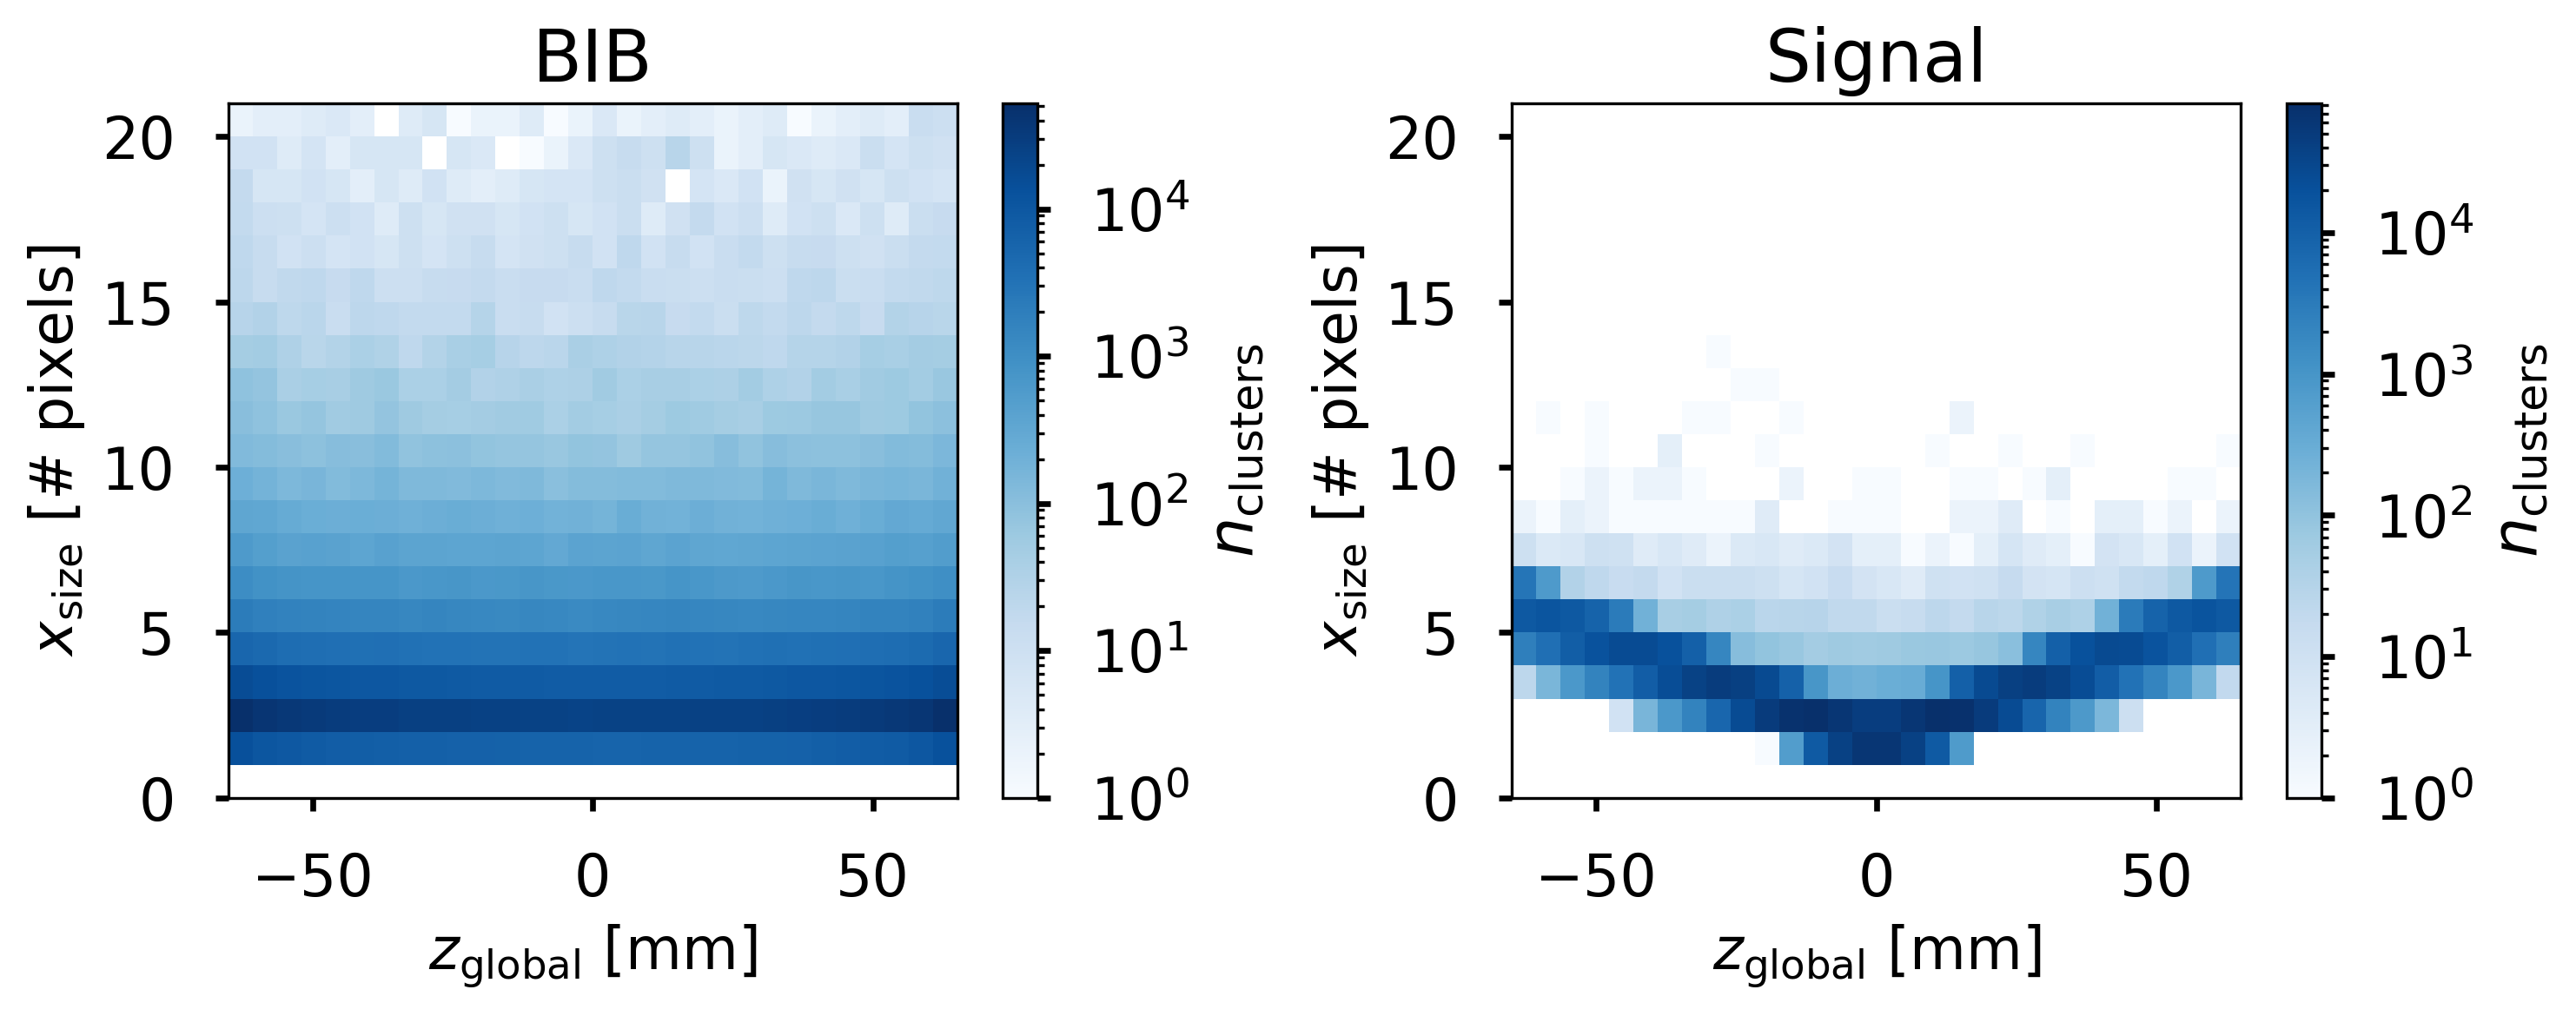

Plot saved as: ../datasetPlots/bib_signal_zglobal_vs_xsize_comparison.png
cut:  None
number BIB clusters  1656656 number of signal clusters  1717087
fraction of total bib  1.0  fraction of total signal  1.0


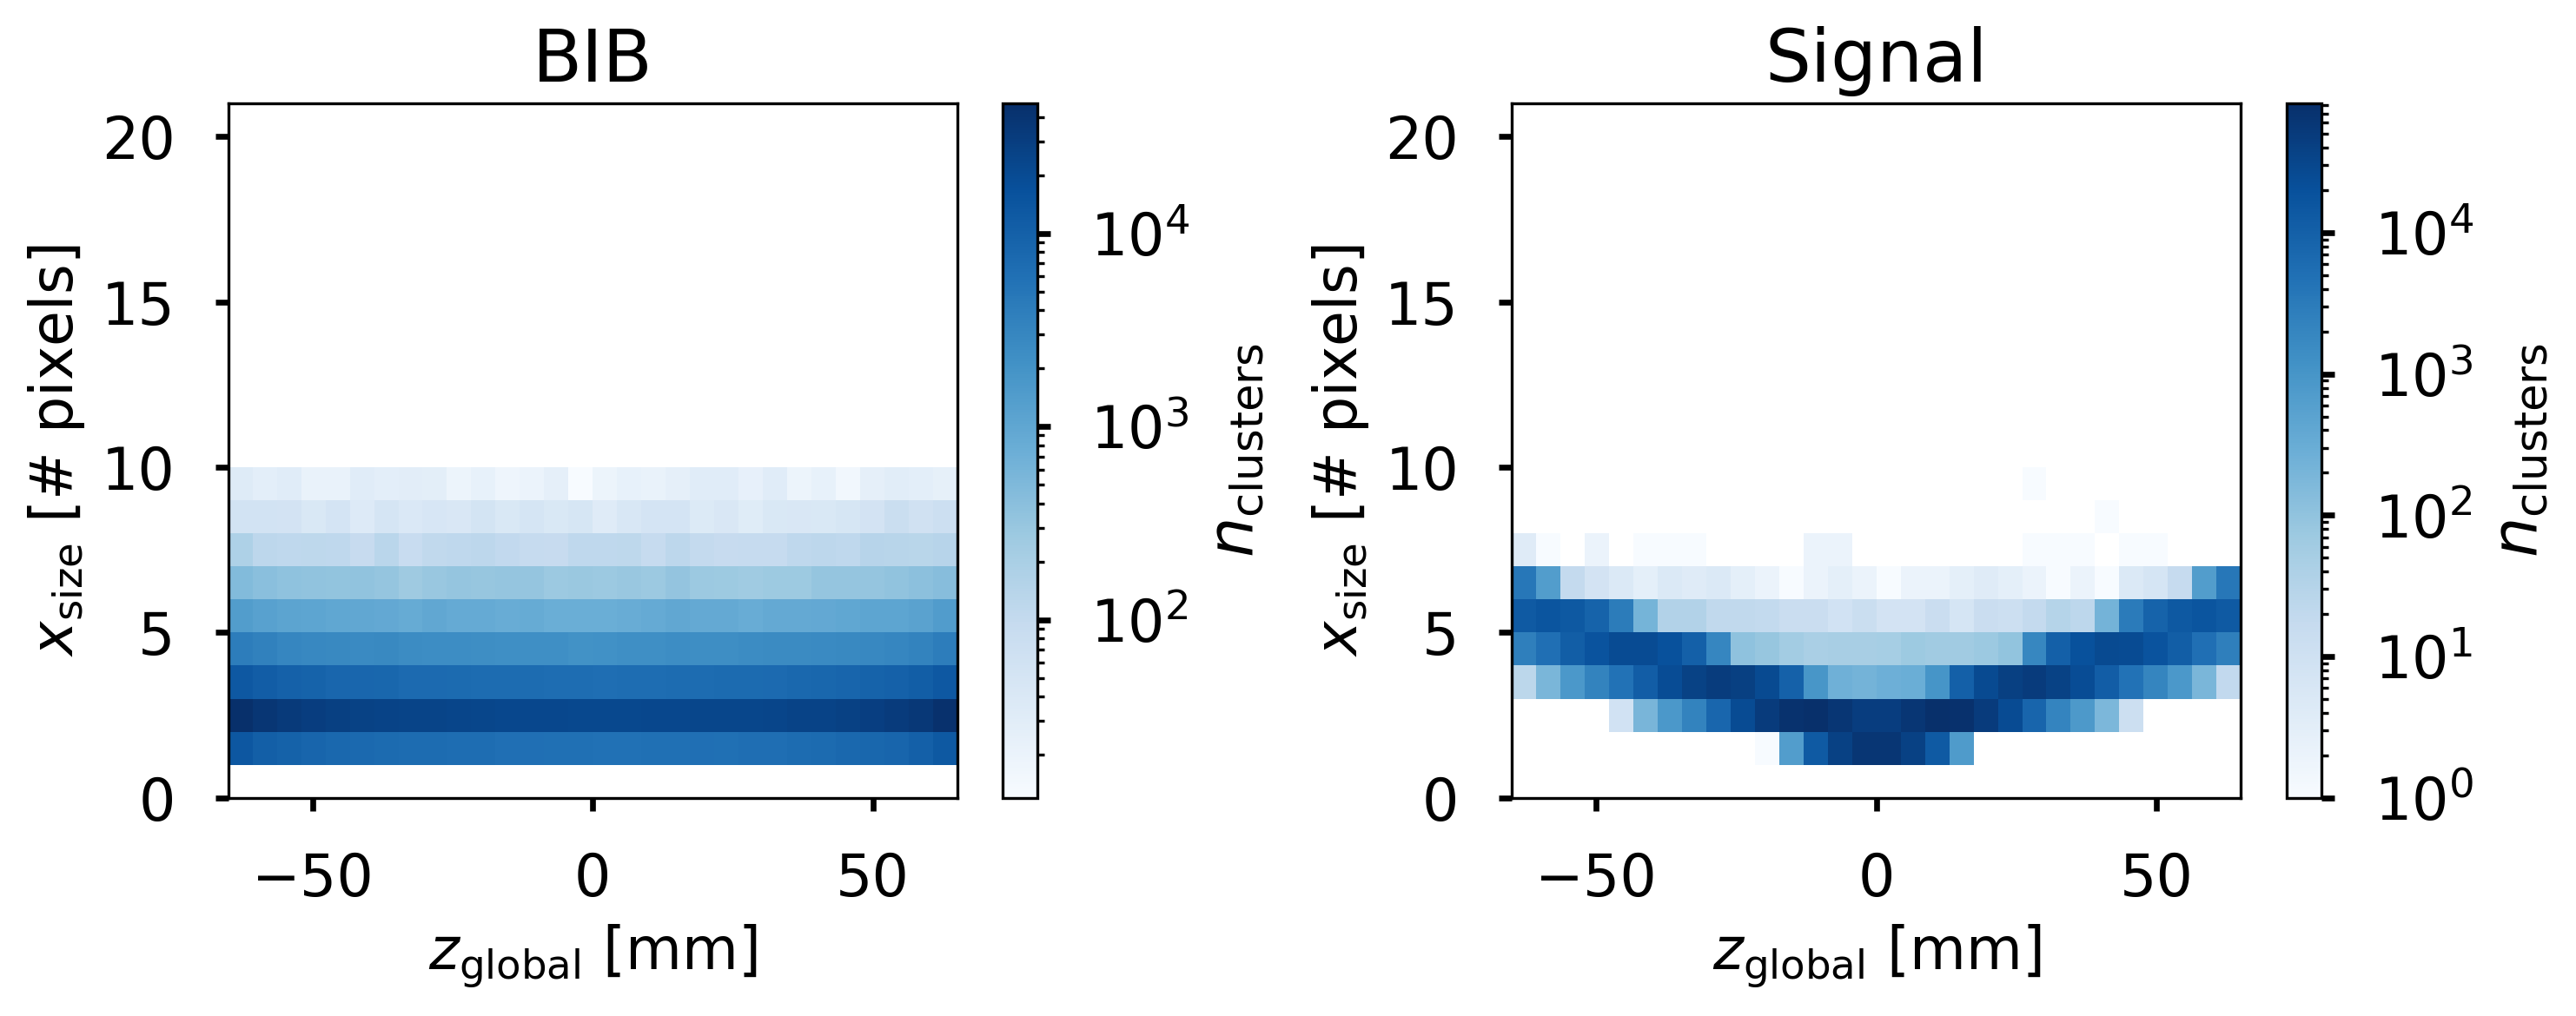

Plot saved as: ../datasetPlots/bib_signal_zglobal_vs_xsize_comparison.png
cut:  nPix < 10
number BIB clusters  1424631 number of signal clusters  1710524
fraction of total bib  0.8599437662375291  fraction of total signal  0.9961778290791323


In [103]:
plotHaha(plotter.truthBib,plotter.truthSig,plotZgXs=True,plotNpEt=False)
cut1="nPix < 10"
# truthBibCut1 = plotter.truthBib.query(cut1); truthSigCut1 = plotter.truthSig.query(cut1)
# print("done cutting")
plotHaha(plotter.truthBib,plotter.truthSig,cut1,plotZgXs=True,plotNpEt=False)

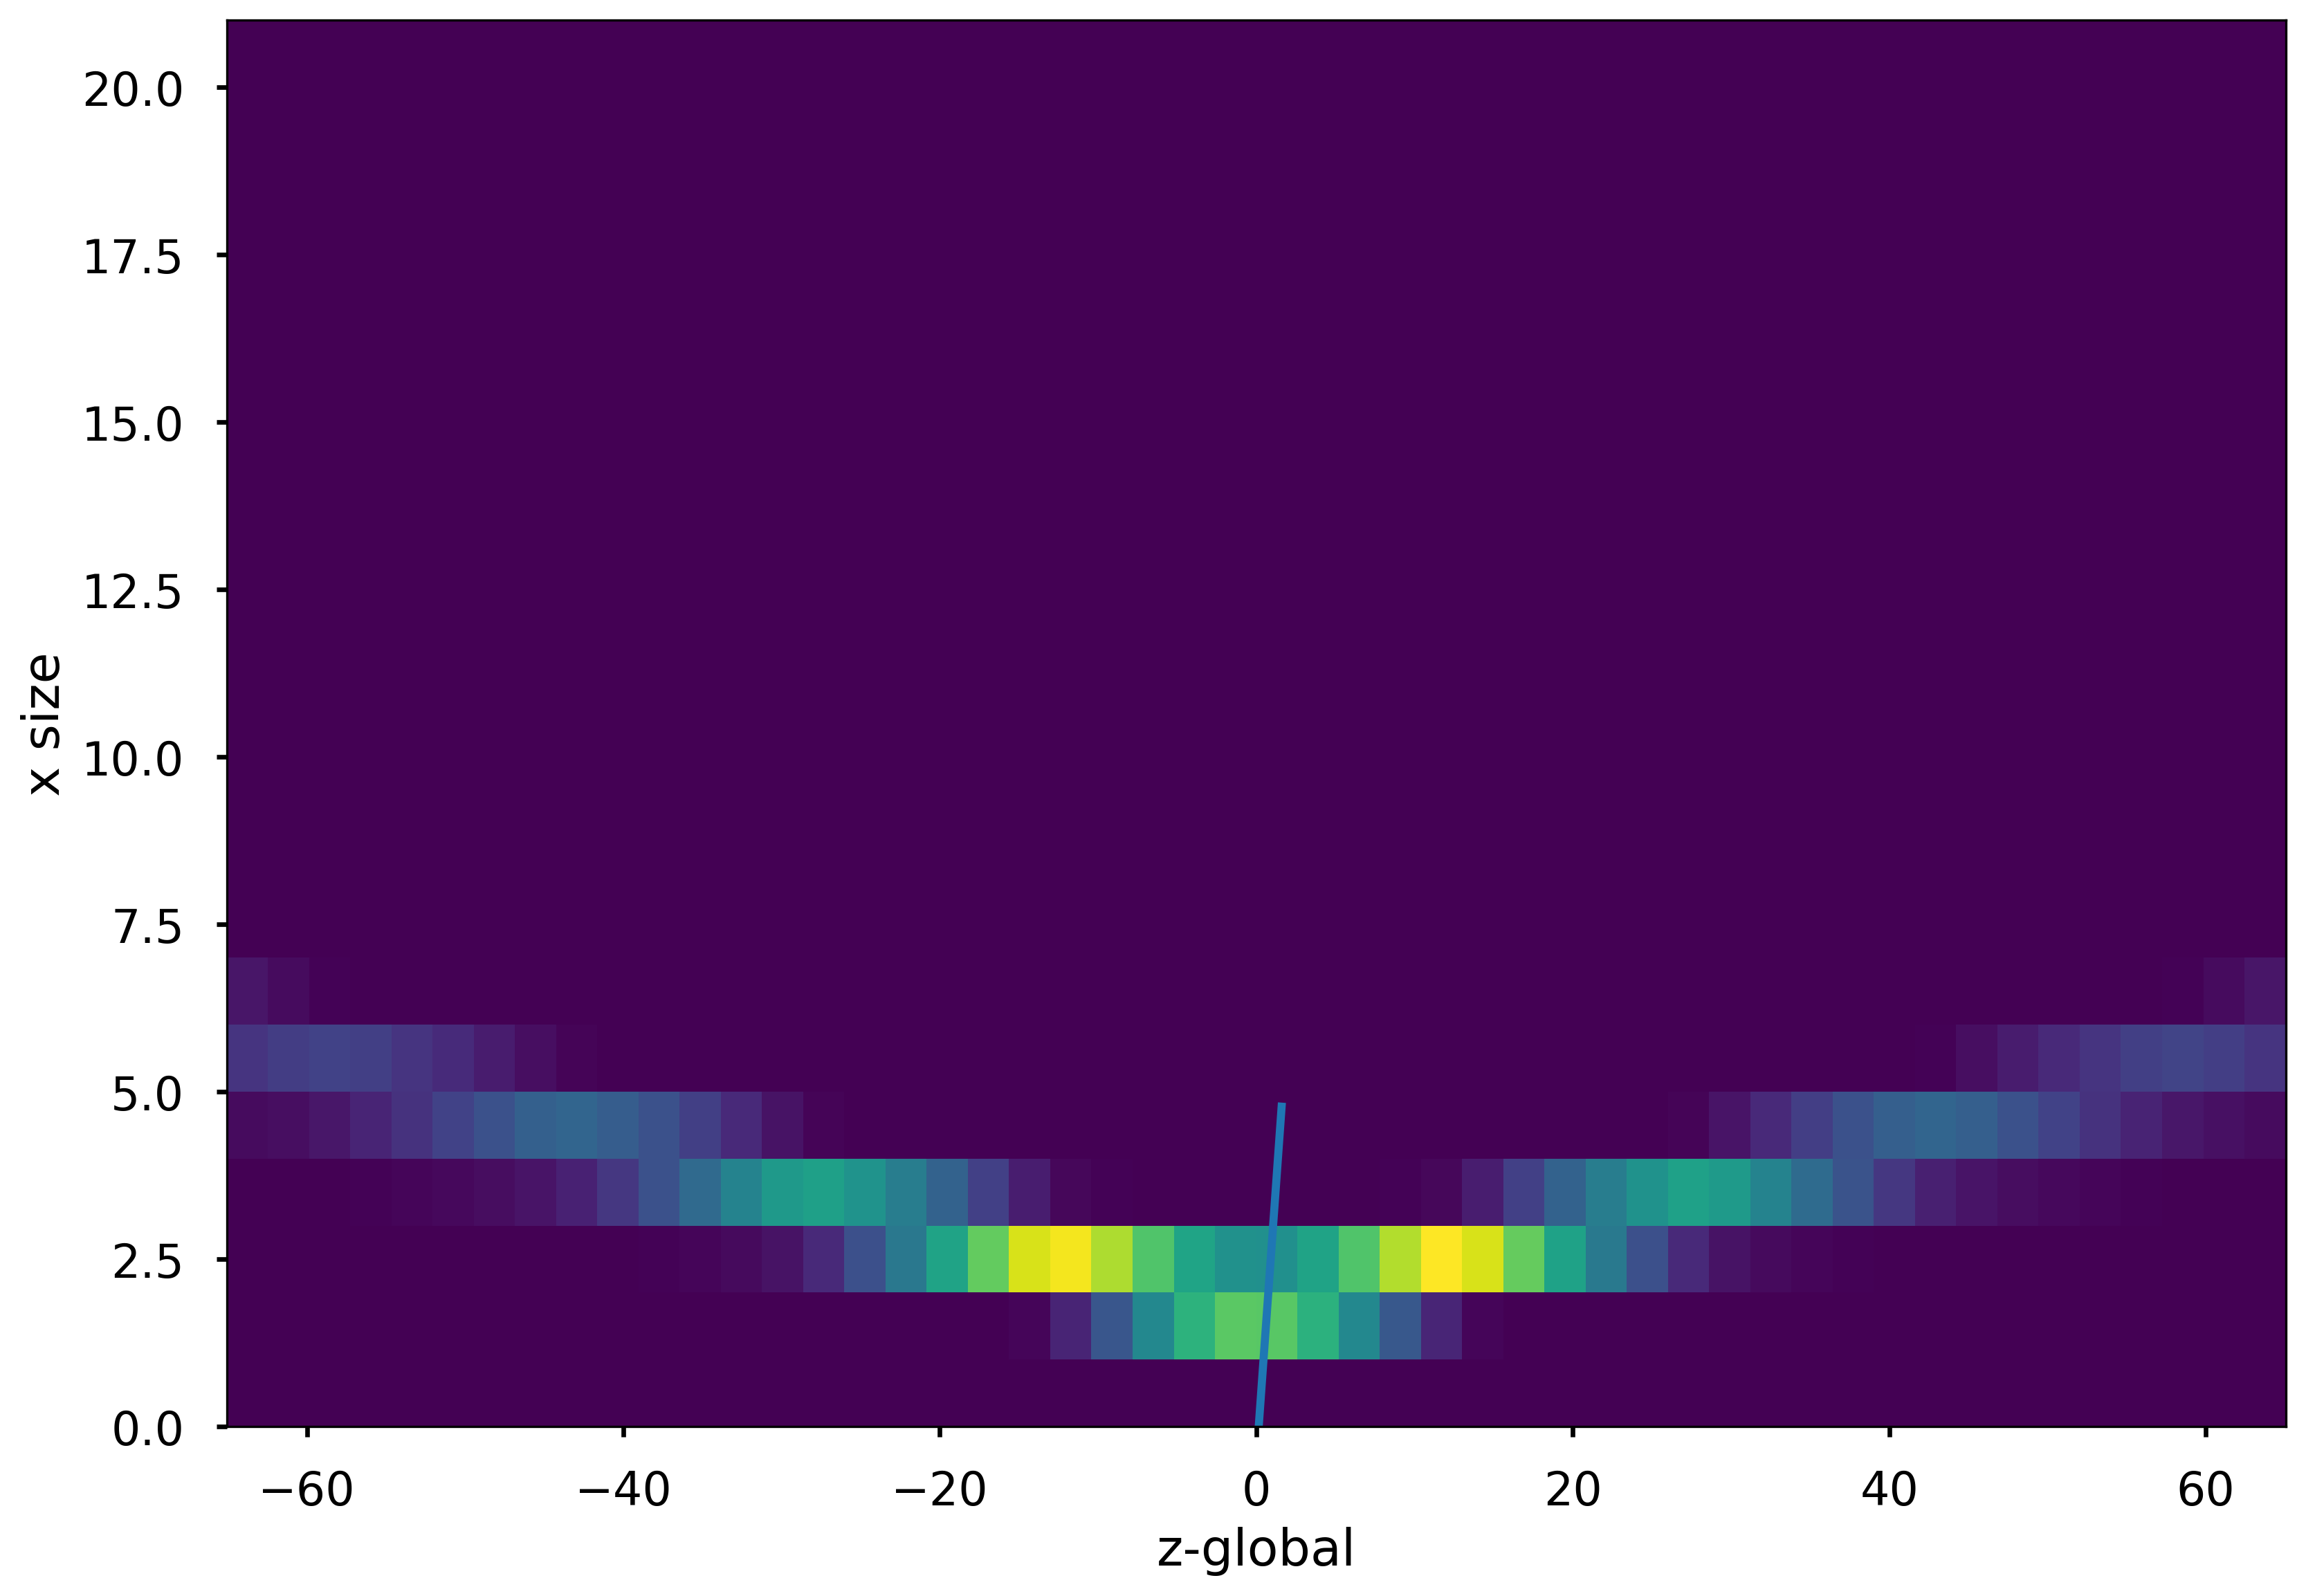

In [98]:
plt.hist2d(plotter.truthSig["z-global"],plotter.truthSig["xSize"],bins=(50,np.arange(0,22,1)))
plt.xlabel("z-global");plt.ylabel("x size")
sampleEtas = np.linspace(0,1.6,10)
plt.plot(sampleEtas,sampleEtas*5/1.516-0.5)
plt.show()

a = 0.03724 ± 0.00206
b = 1.2885  ± 0.0772


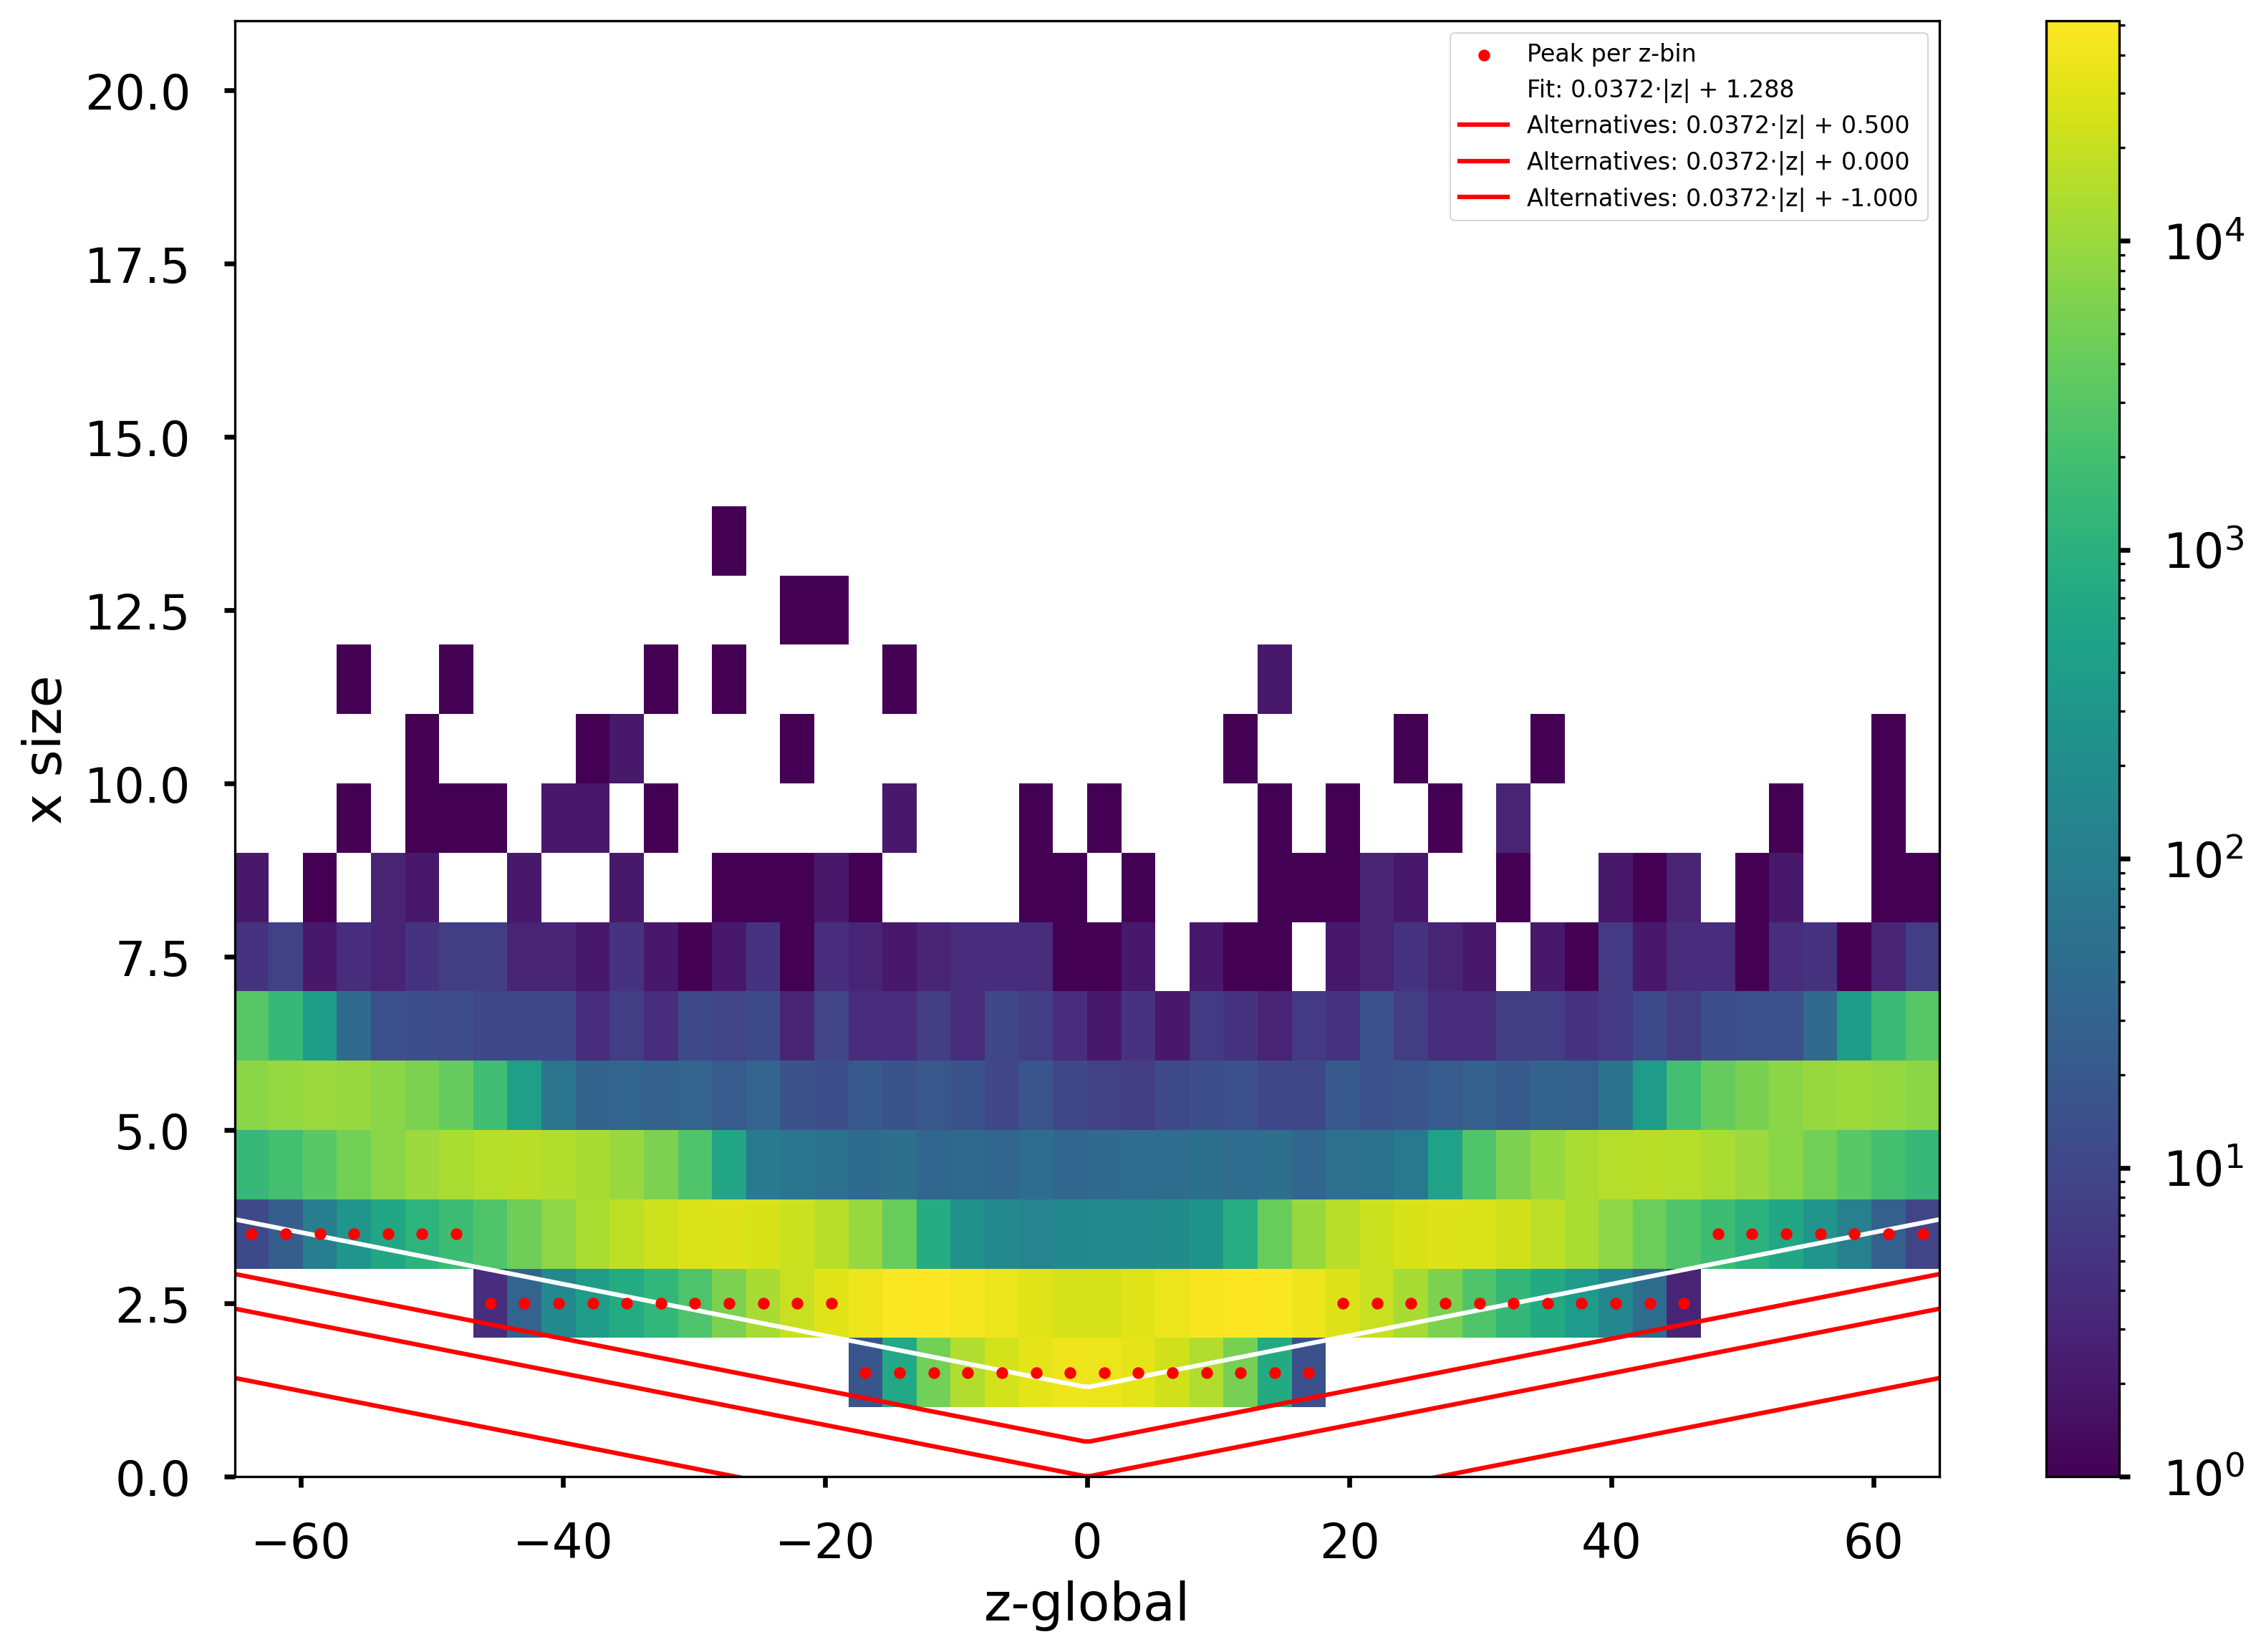

In [147]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.optimize import curve_fit

# --- 1. Build the histogram and capture the return values ---
fig, ax = plt.subplots()
counts, z_edges, xsize_edges, img = ax.hist2d(
    plotter.truthSig["z-global"],
    plotter.truthSig["xSize"],
    bins=(50, np.arange(0, 22, 1)),
    norm=matplotlib.colors.LogNorm()
)
# counts.shape == (n_z_bins, n_xsize_bins)

# --- 2. Compute bin centers ---
z_centers     = (z_edges[:-1]     + z_edges[1:])     / 2   # shape (50,)
xsize_centers = (xsize_edges[:-1] + xsize_edges[1:]) / 2   # shape (21,)

# --- 3. For each z column, find the xSize bin with the highest count ---
peak_xsize_idx = np.argmax(counts, axis=1)          # shape (50,)
peak_xsize     = xsize_centers[peak_xsize_idx]       # shape (50,)

def first_nonzero_xsize(col_counts, xsize_centers):
    nonzero_idx = np.nonzero(col_counts)[0]
    return xsize_centers[nonzero_idx[0]] if len(nonzero_idx) > 0 else np.nan

min_xsize = np.array([first_nonzero_xsize(counts[i], xsize_centers)
                      for i in range(len(z_centers))])  # shape (50,)

# --- 4. Drop empty columns (no data → argmax is meaningless) ---
has_data   = counts.max(axis=1) > 0
z_fit      = z_centers[has_data]
fitPeakLine=False
if fitPeakLine:
        xsize_fit  = peak_xsize[has_data]
else:
        xsize_fit  = min_xsize[has_data]

# --- 4. Abs function fit ---
def abs_model(z, a, b):
    return a * np.abs(z) + b

popt, pcov = curve_fit(abs_model, z_fit, xsize_fit, p0=[0.03, 2.0])
a, b = popt
perr = np.sqrt(np.diag(pcov))
print(f"a = {a:.5f} ± {perr[0]:.5f}")
print(f"b = {b:.4f}  ± {perr[1]:.4f}")

# --- 5. Overlay ---
ax.scatter(z_fit, xsize_fit, color='red', s=12, zorder=5, label='Peak per z-bin')
z_line = np.linspace(z_edges[0], z_edges[-1], 300)
ax.plot(z_line, abs_model(z_line, *popt),
        color='white', lw=1.5, label=f'Fit: {a:.4f}·|z| + {b:.3f}')

bCustom=0.5
ax.plot(z_line, abs_model(z_line, a,bCustom),
        color='red', lw=1.5, label=f'Alternatives: {a:.4f}·|z| + {bCustom:.3f}')

bCustom=0
ax.plot(z_line, abs_model(z_line, a,bCustom),
        color='red', lw=1.5, label=f'Alternatives: {a:.4f}·|z| + {bCustom:.3f}')

bCustom=-1
ax.plot(z_line, abs_model(z_line, a,bCustom),
        color='red', lw=1.5, label=f'Alternatives: {a:.4f}·|z| + {bCustom:.3f}')


# # Your original eta line
# sampleEtas = np.linspace(0, 1.6, 10)
# ax.plot(sampleEtas, sampleEtas * 5 / 1.516 - 0.5, color='cyan')

ax.set_xlabel("z-global")
ax.set_ylabel("x size")
ax.legend(fontsize=8)
plt.colorbar(img, ax=ax)
plt.show()

((`z-global`<-62.472497059999995 and `z-global`>-65.074997 and xSize>=3.5) or (`z-global`<-59.869997119999994 and `z-global`>-62.472497059999995 and xSize>=3.5) or (`z-global`<-57.26749717999999 and `z-global`>-59.869997119999994 and xSize>=3.5) or (`z-global`<-54.66499724 and `z-global`>-57.26749717999999 and xSize>=3.5) or (`z-global`<-52.0624973 and `z-global`>-54.66499724 and xSize>=3.5) or (`z-global`<-49.459997359999996 and `z-global`>-52.0624973 and xSize>=3.5) or (`z-global`<-46.85749742 and `z-global`>-49.459997359999996 and xSize>=3.5) or (`z-global`<-44.25499748 and `z-global`>-46.85749742 and xSize>=2.5) or (`z-global`<-41.65249754 and `z-global`>-44.25499748 and xSize>=2.5) or (`z-global`<-39.0499976 and `z-global`>-41.65249754 and xSize>=2.5) or (`z-global`<-36.447497659999996 and `z-global`>-39.0499976 and xSize>=2.5) or (`z-global`<-33.844997719999995 and `z-global`>-36.447497659999996 and xSize>=2.5) or (`z-global`<-31.242497779999994 and `z-global`>-33.844997719999995

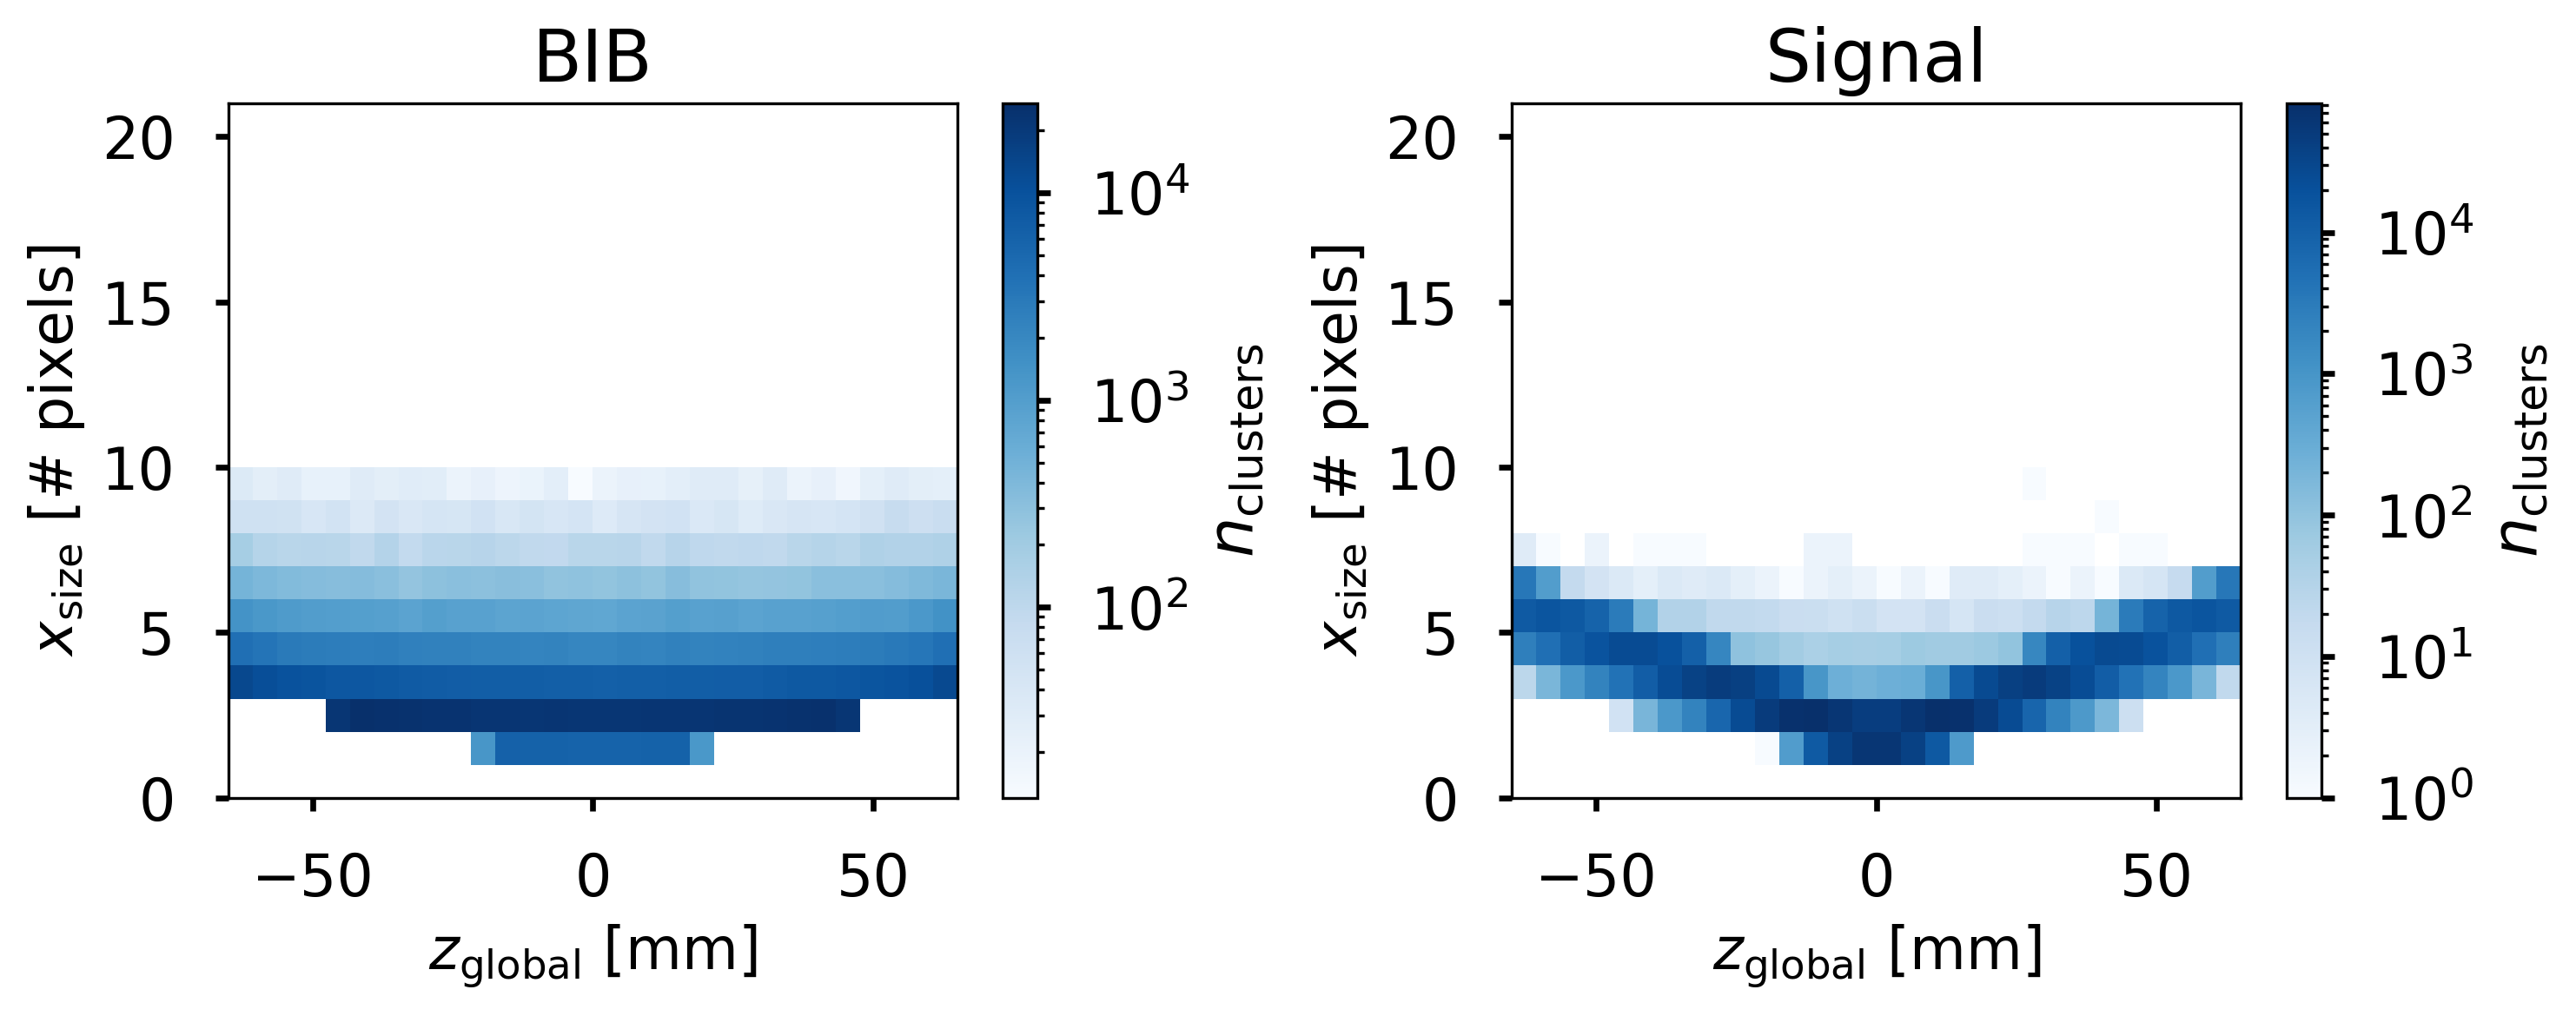

Plot saved as: ../datasetPlots/bib_signal_zglobal_vs_xsize_comparison.png
cut:  ((`z-global`<-62.472497059999995 and `z-global`>-65.074997 and xSize>=3.0) or (`z-global`<-59.869997119999994 and `z-global`>-62.472497059999995 and xSize>=3.0) or (`z-global`<-57.26749717999999 and `z-global`>-59.869997119999994 and xSize>=3.0) or (`z-global`<-54.66499724 and `z-global`>-57.26749717999999 and xSize>=3.0) or (`z-global`<-52.0624973 and `z-global`>-54.66499724 and xSize>=3.0) or (`z-global`<-49.459997359999996 and `z-global`>-52.0624973 and xSize>=3.0) or (`z-global`<-46.85749742 and `z-global`>-49.459997359999996 and xSize>=3.0) or (`z-global`<-44.25499748 and `z-global`>-46.85749742 and xSize>=2.0) or (`z-global`<-41.65249754 and `z-global`>-44.25499748 and xSize>=2.0) or (`z-global`<-39.0499976 and `z-global`>-41.65249754 and xSize>=2.0) or (`z-global`<-36.447497659999996 and `z-global`>-39.0499976 and xSize>=2.0) or (`z-global`<-33.844997719999995 and `z-global`>-36.447497659999996 and x

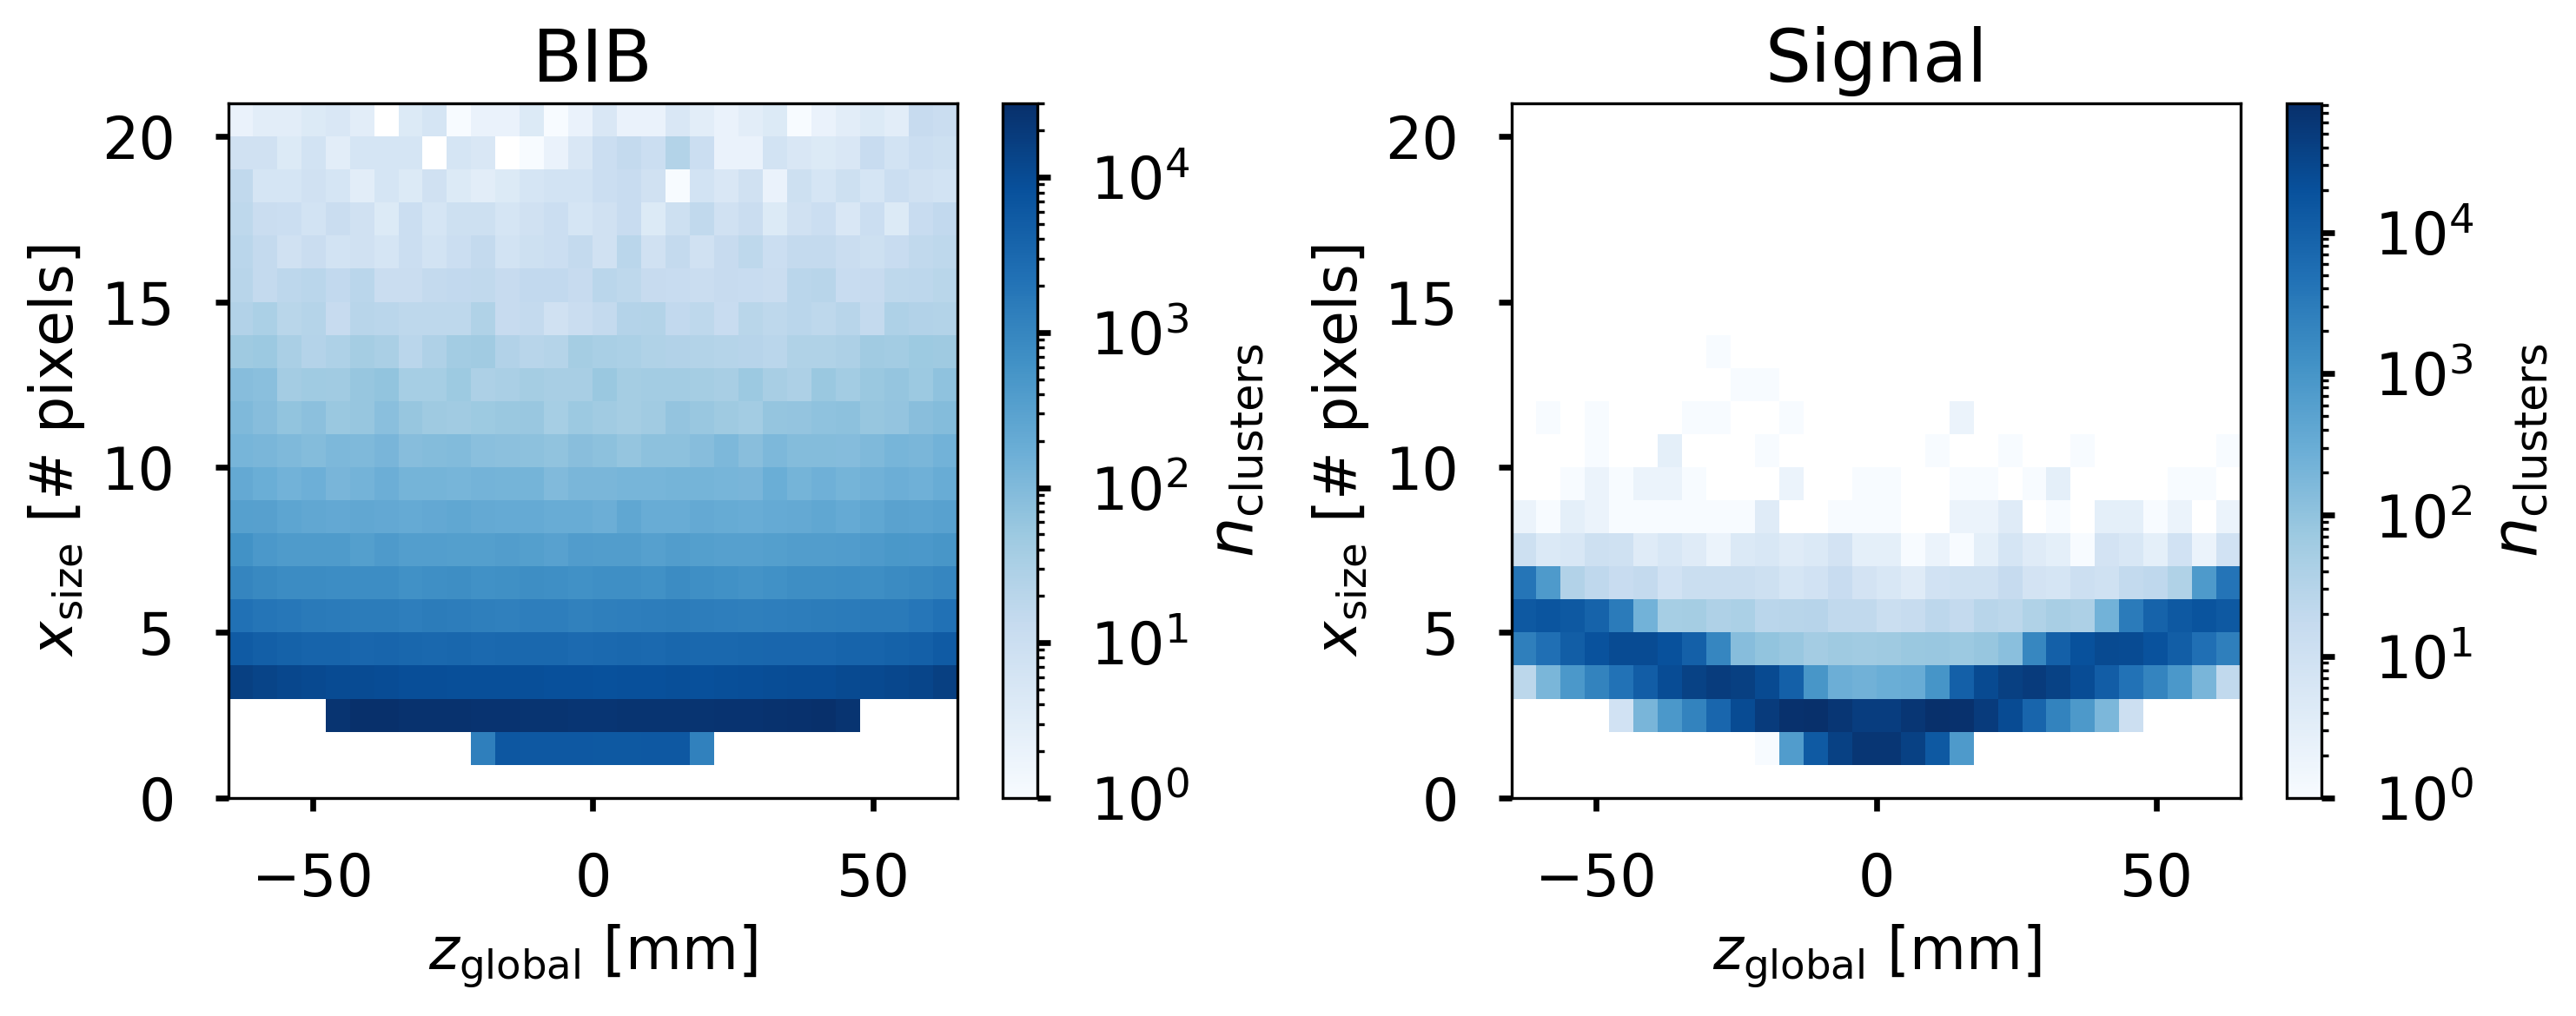

Plot saved as: ../datasetPlots/bib_signal_zglobal_vs_xsize_comparison.png
cut:  (`z-global`<-62.472497059999995 and `z-global`>-65.074997 and xSize>=3.0) or (`z-global`<-59.869997119999994 and `z-global`>-62.472497059999995 and xSize>=3.0) or (`z-global`<-57.26749717999999 and `z-global`>-59.869997119999994 and xSize>=3.0) or (`z-global`<-54.66499724 and `z-global`>-57.26749717999999 and xSize>=3.0) or (`z-global`<-52.0624973 and `z-global`>-54.66499724 and xSize>=3.0) or (`z-global`<-49.459997359999996 and `z-global`>-52.0624973 and xSize>=3.0) or (`z-global`<-46.85749742 and `z-global`>-49.459997359999996 and xSize>=3.0) or (`z-global`<-44.25499748 and `z-global`>-46.85749742 and xSize>=2.0) or (`z-global`<-41.65249754 and `z-global`>-44.25499748 and xSize>=2.0) or (`z-global`<-39.0499976 and `z-global`>-41.65249754 and xSize>=2.0) or (`z-global`<-36.447497659999996 and `z-global`>-39.0499976 and xSize>=2.0) or (`z-global`<-33.844997719999995 and `z-global`>-36.447497659999996 and xS

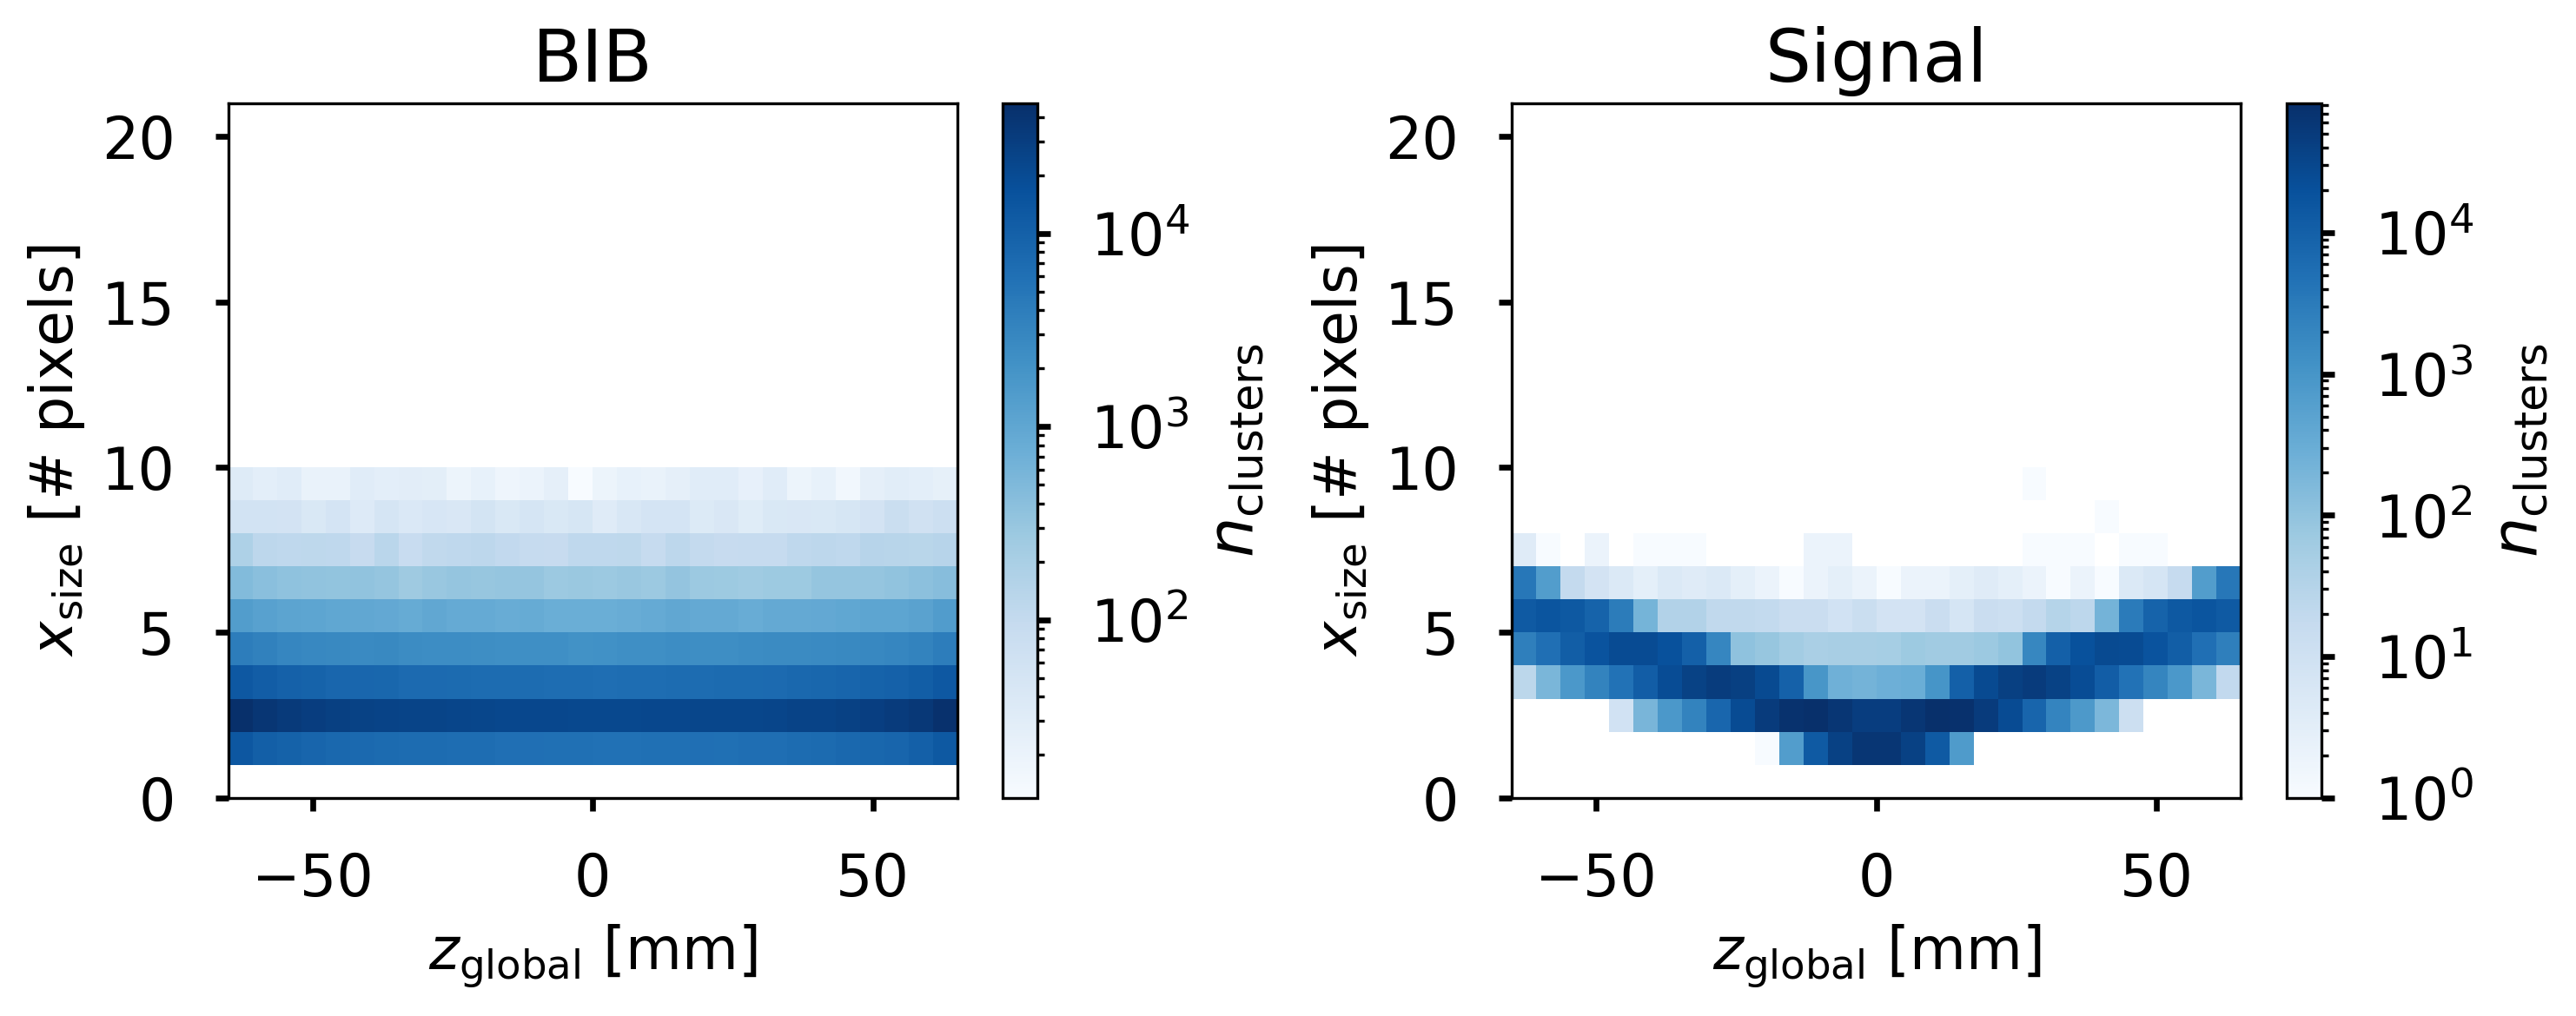

Plot saved as: ../datasetPlots/bib_signal_zglobal_vs_xsize_comparison.png
cut:  (nPix<10) and (xSize > `z-global`*0.0372422809955313 + -2.0) and (xSize > `z-global`*-0.0372422809955313 + -2.0)
number BIB clusters  1424631 number of signal clusters  1710524
fraction of total bib  0.8599437662375291  fraction of total signal  0.9961778290791323


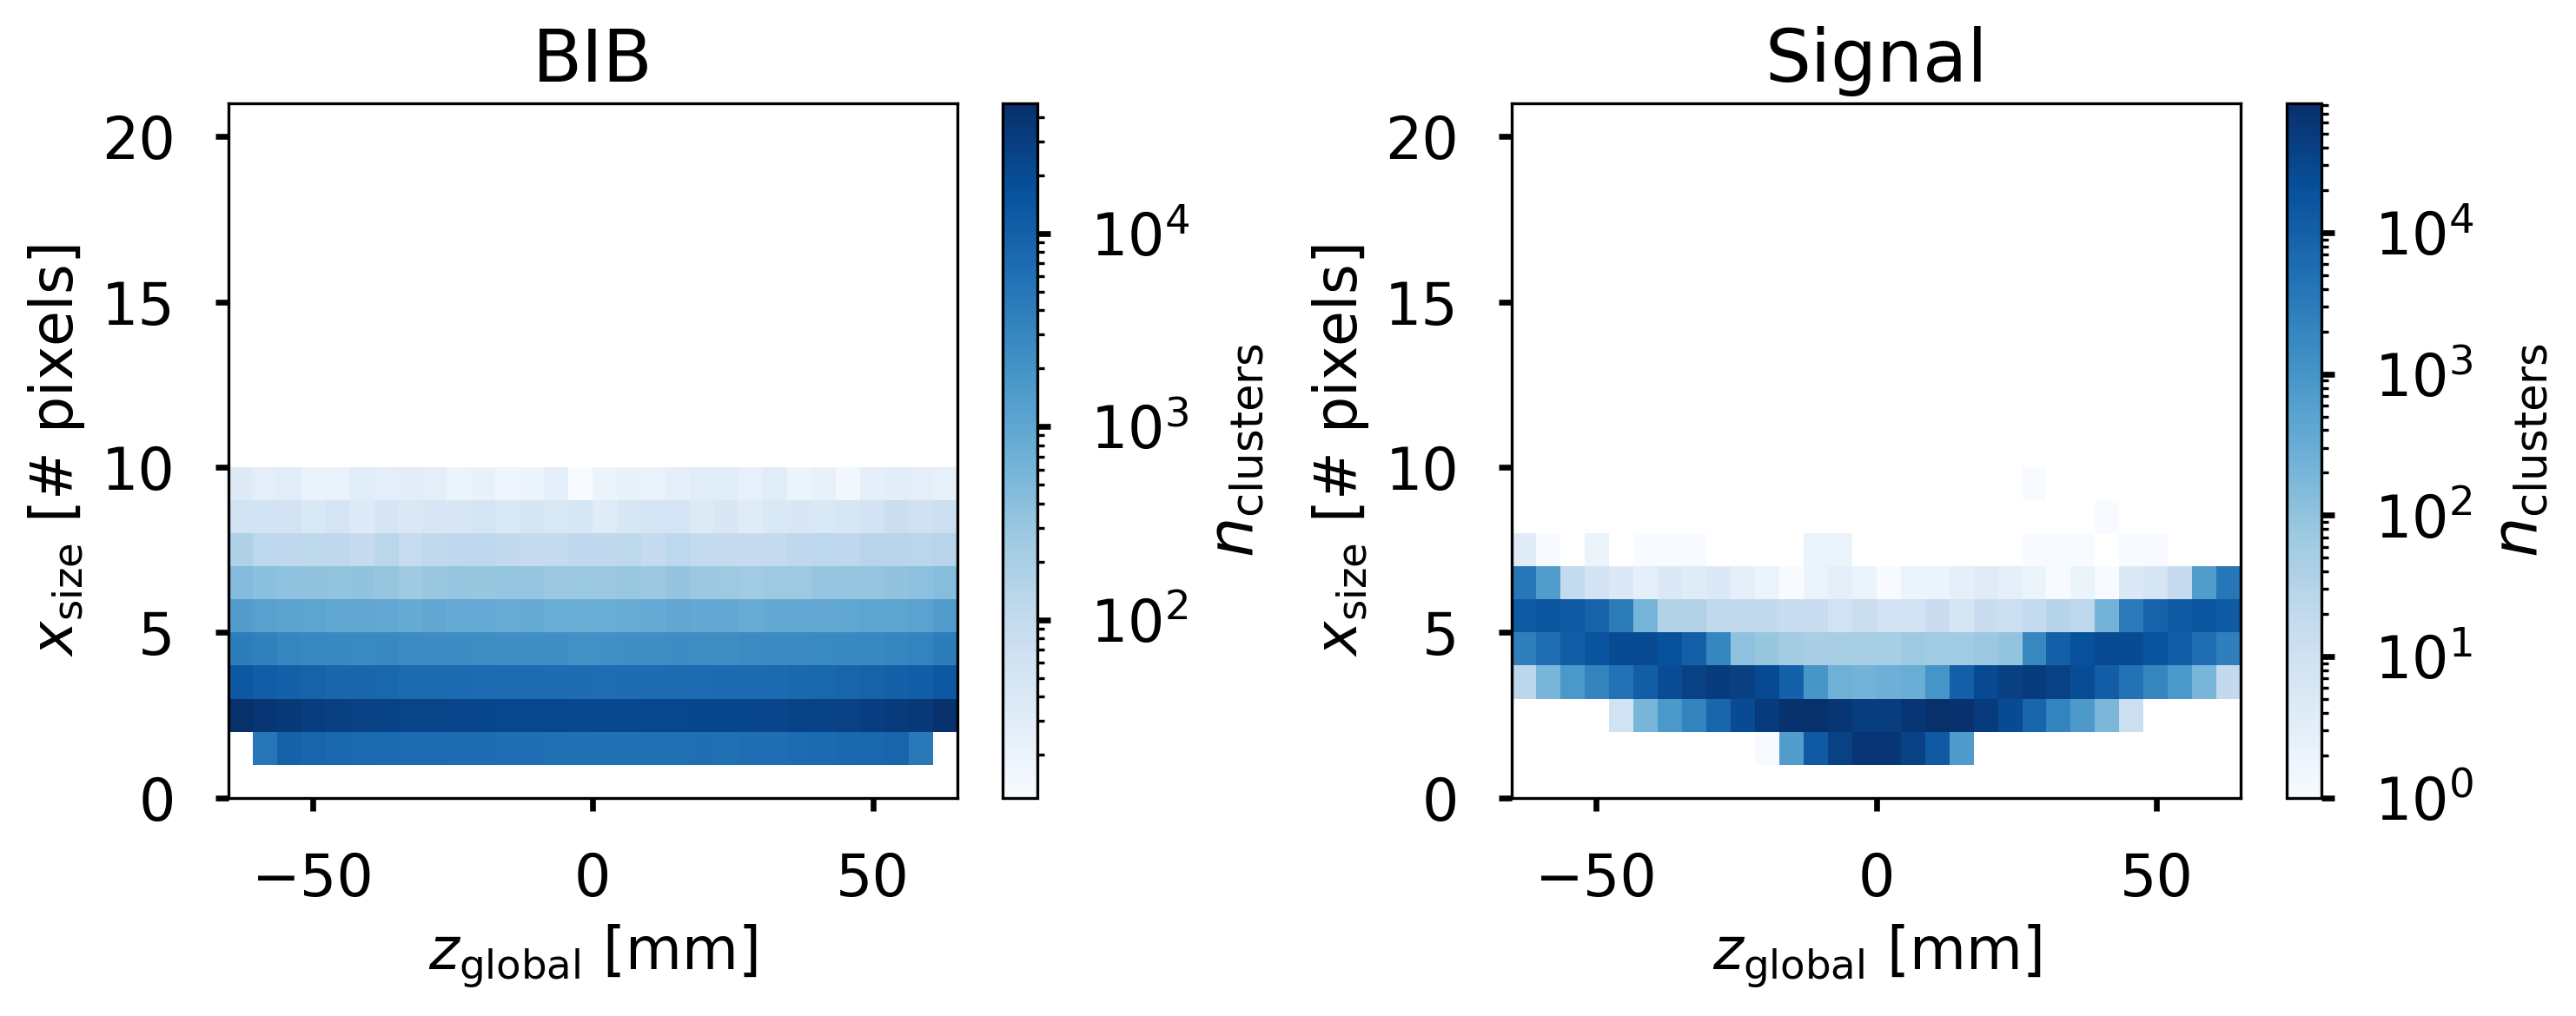

Plot saved as: ../datasetPlots/bib_signal_zglobal_vs_xsize_comparison.png
cut:  (nPix<10) and (xSize > `z-global`*0.0372422809955313 + -1.1778844812733713) and (xSize > `z-global`*-0.0372422809955313 + -1.1778844812733713)
number BIB clusters  1386926 number of signal clusters  1710524
fraction of total bib  0.8371840623521117  fraction of total signal  0.9961778290791323


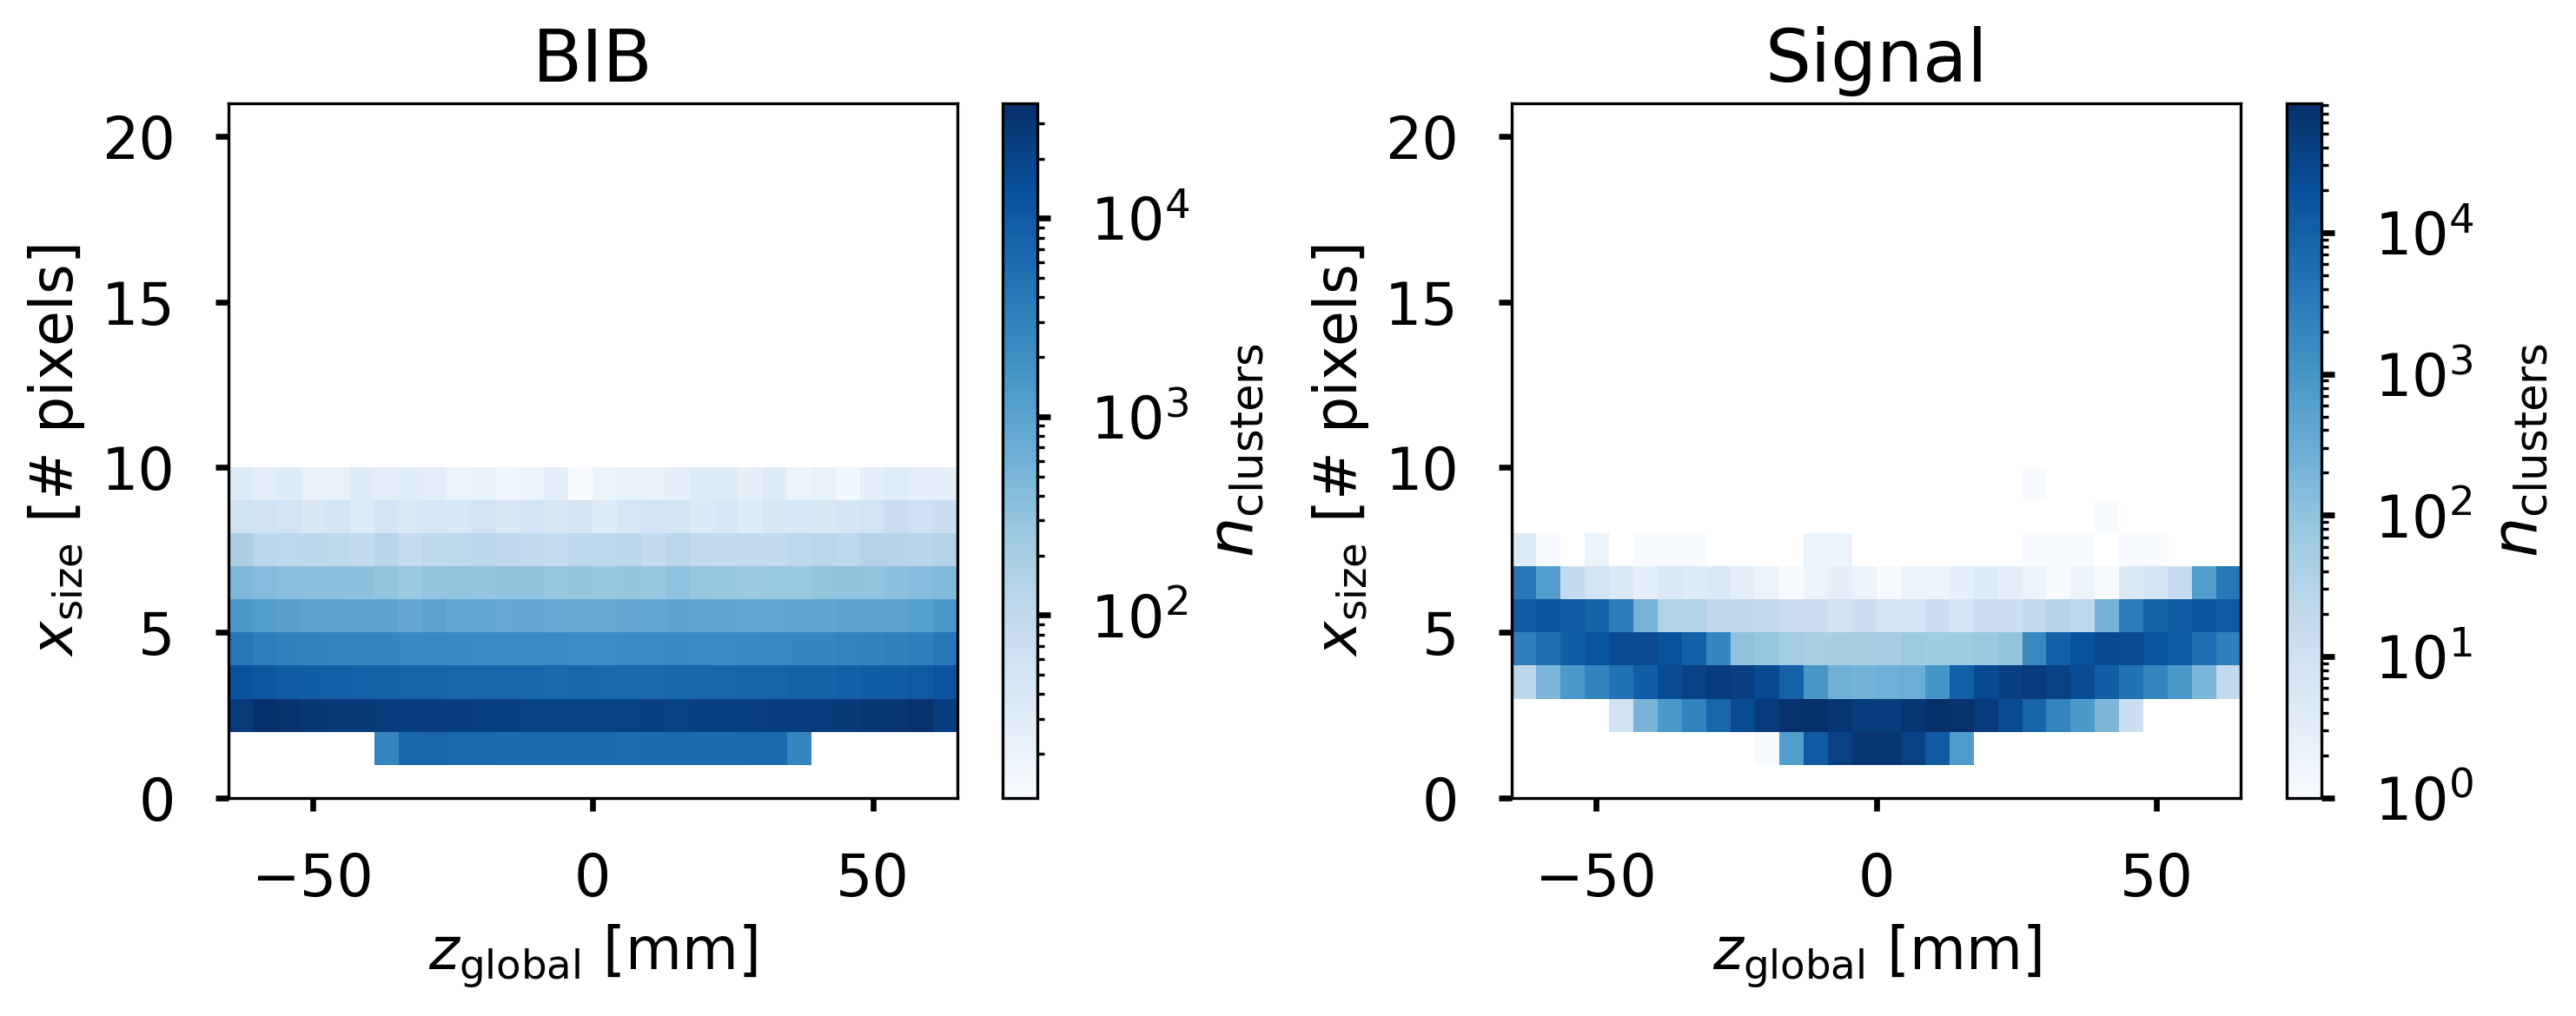

Plot saved as: ../datasetPlots/bib_signal_zglobal_vs_xsize_comparison.png
cut:  (nPix<10) and (xSize > `z-global`*0.0372422809955313 + -0.3557689625467426) and (xSize > `z-global`*-0.0372422809955313 + -0.3557689625467426)
number BIB clusters  1262391 number of signal clusters  1710524
fraction of total bib  0.7620115461508001  fraction of total signal  0.9961778290791323


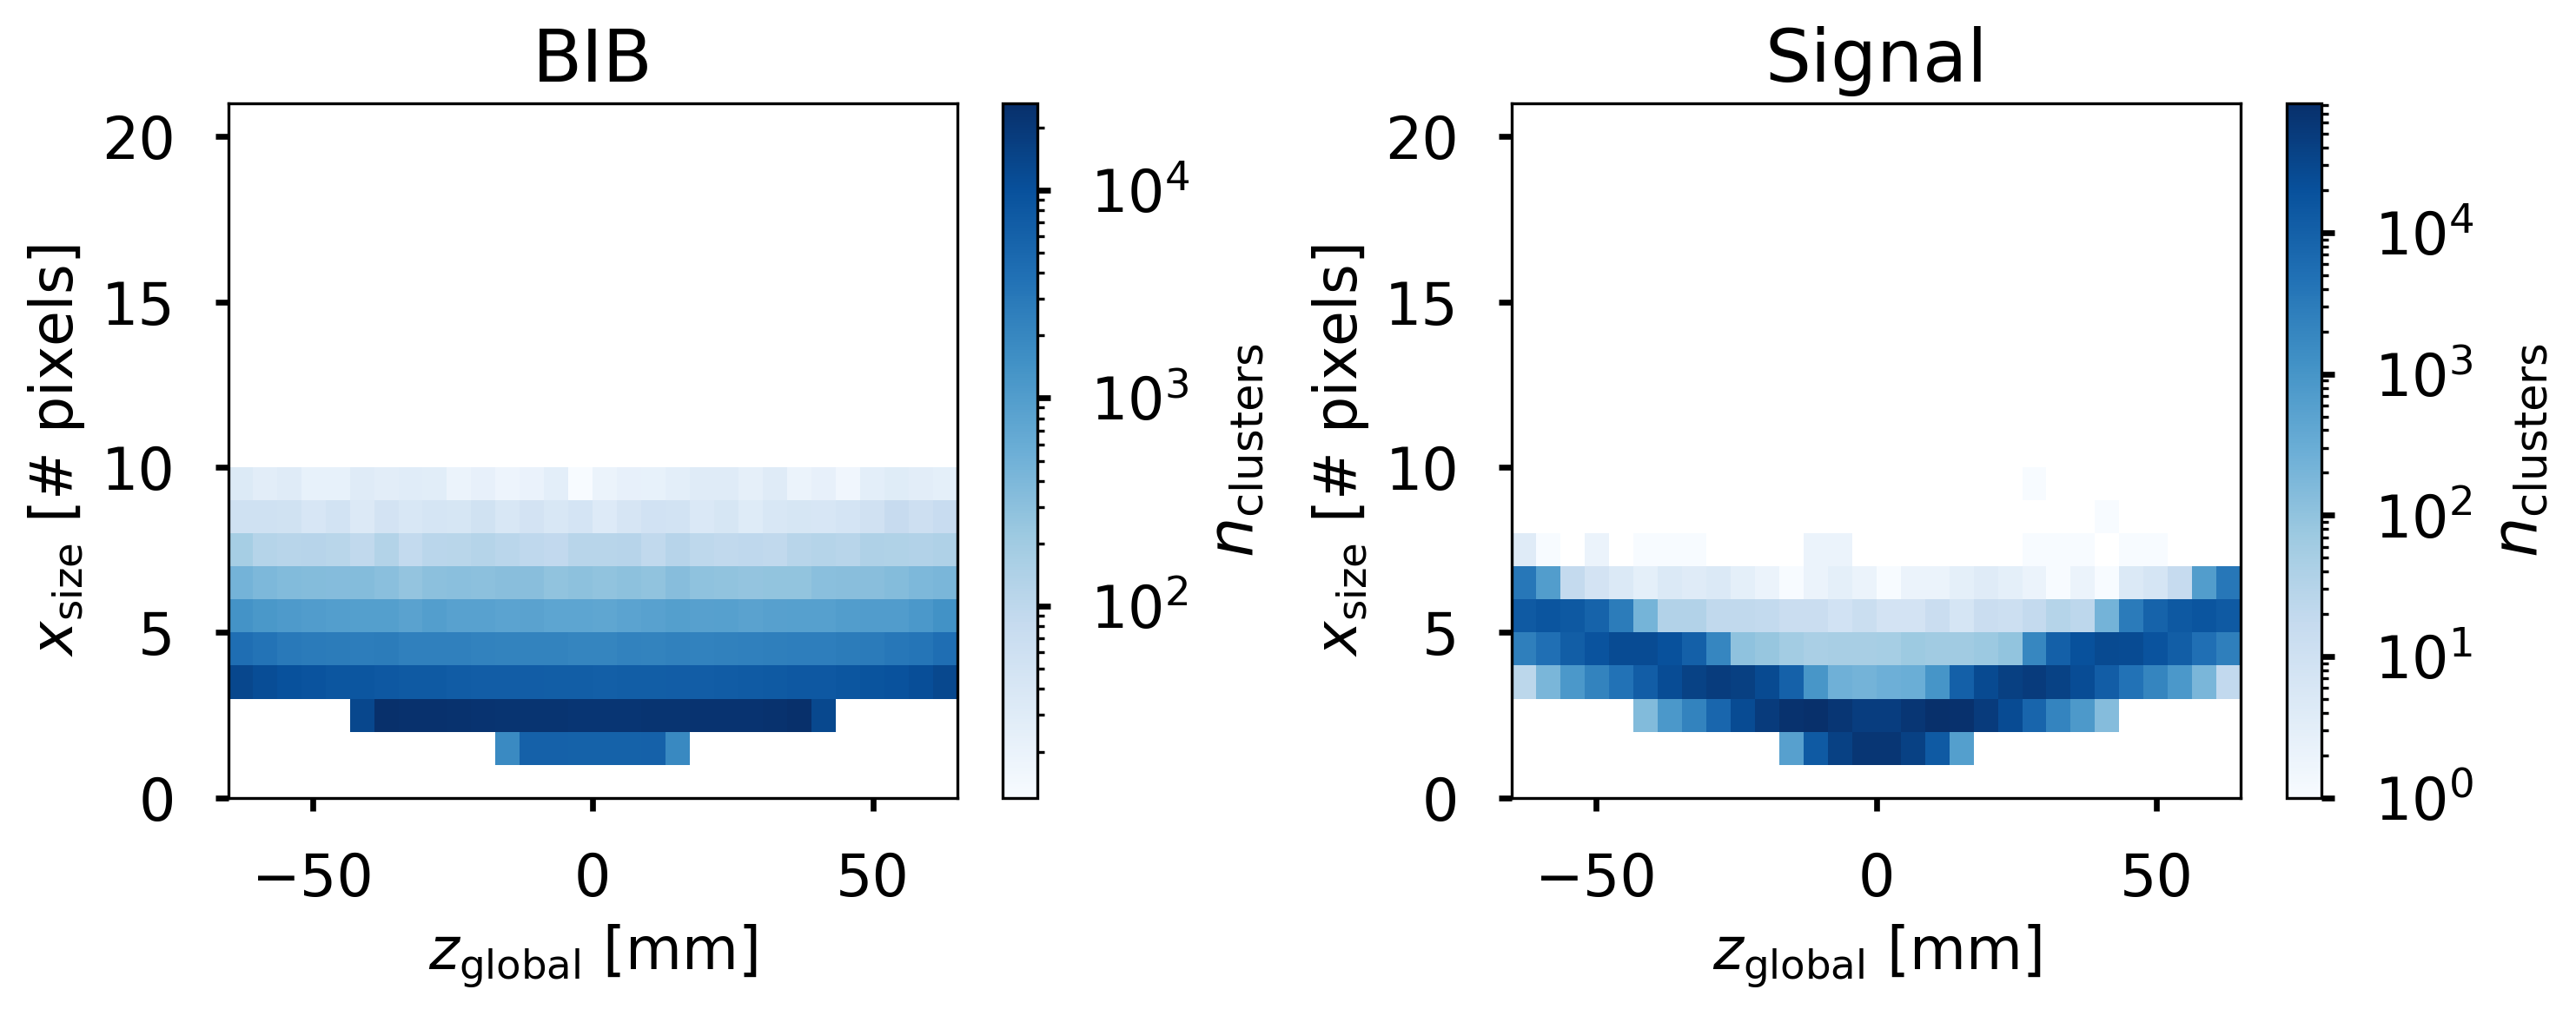

Plot saved as: ../datasetPlots/bib_signal_zglobal_vs_xsize_comparison.png
cut:  (nPix<10) and (xSize > `z-global`*0.0372422809955313 + 0.46634655617988585) and (xSize > `z-global`*-0.0372422809955313 + 0.46634655617988585)
number BIB clusters  861814 number of signal clusters  1710159
fraction of total bib  0.5202130074076936  fraction of total signal  0.9959652597684334


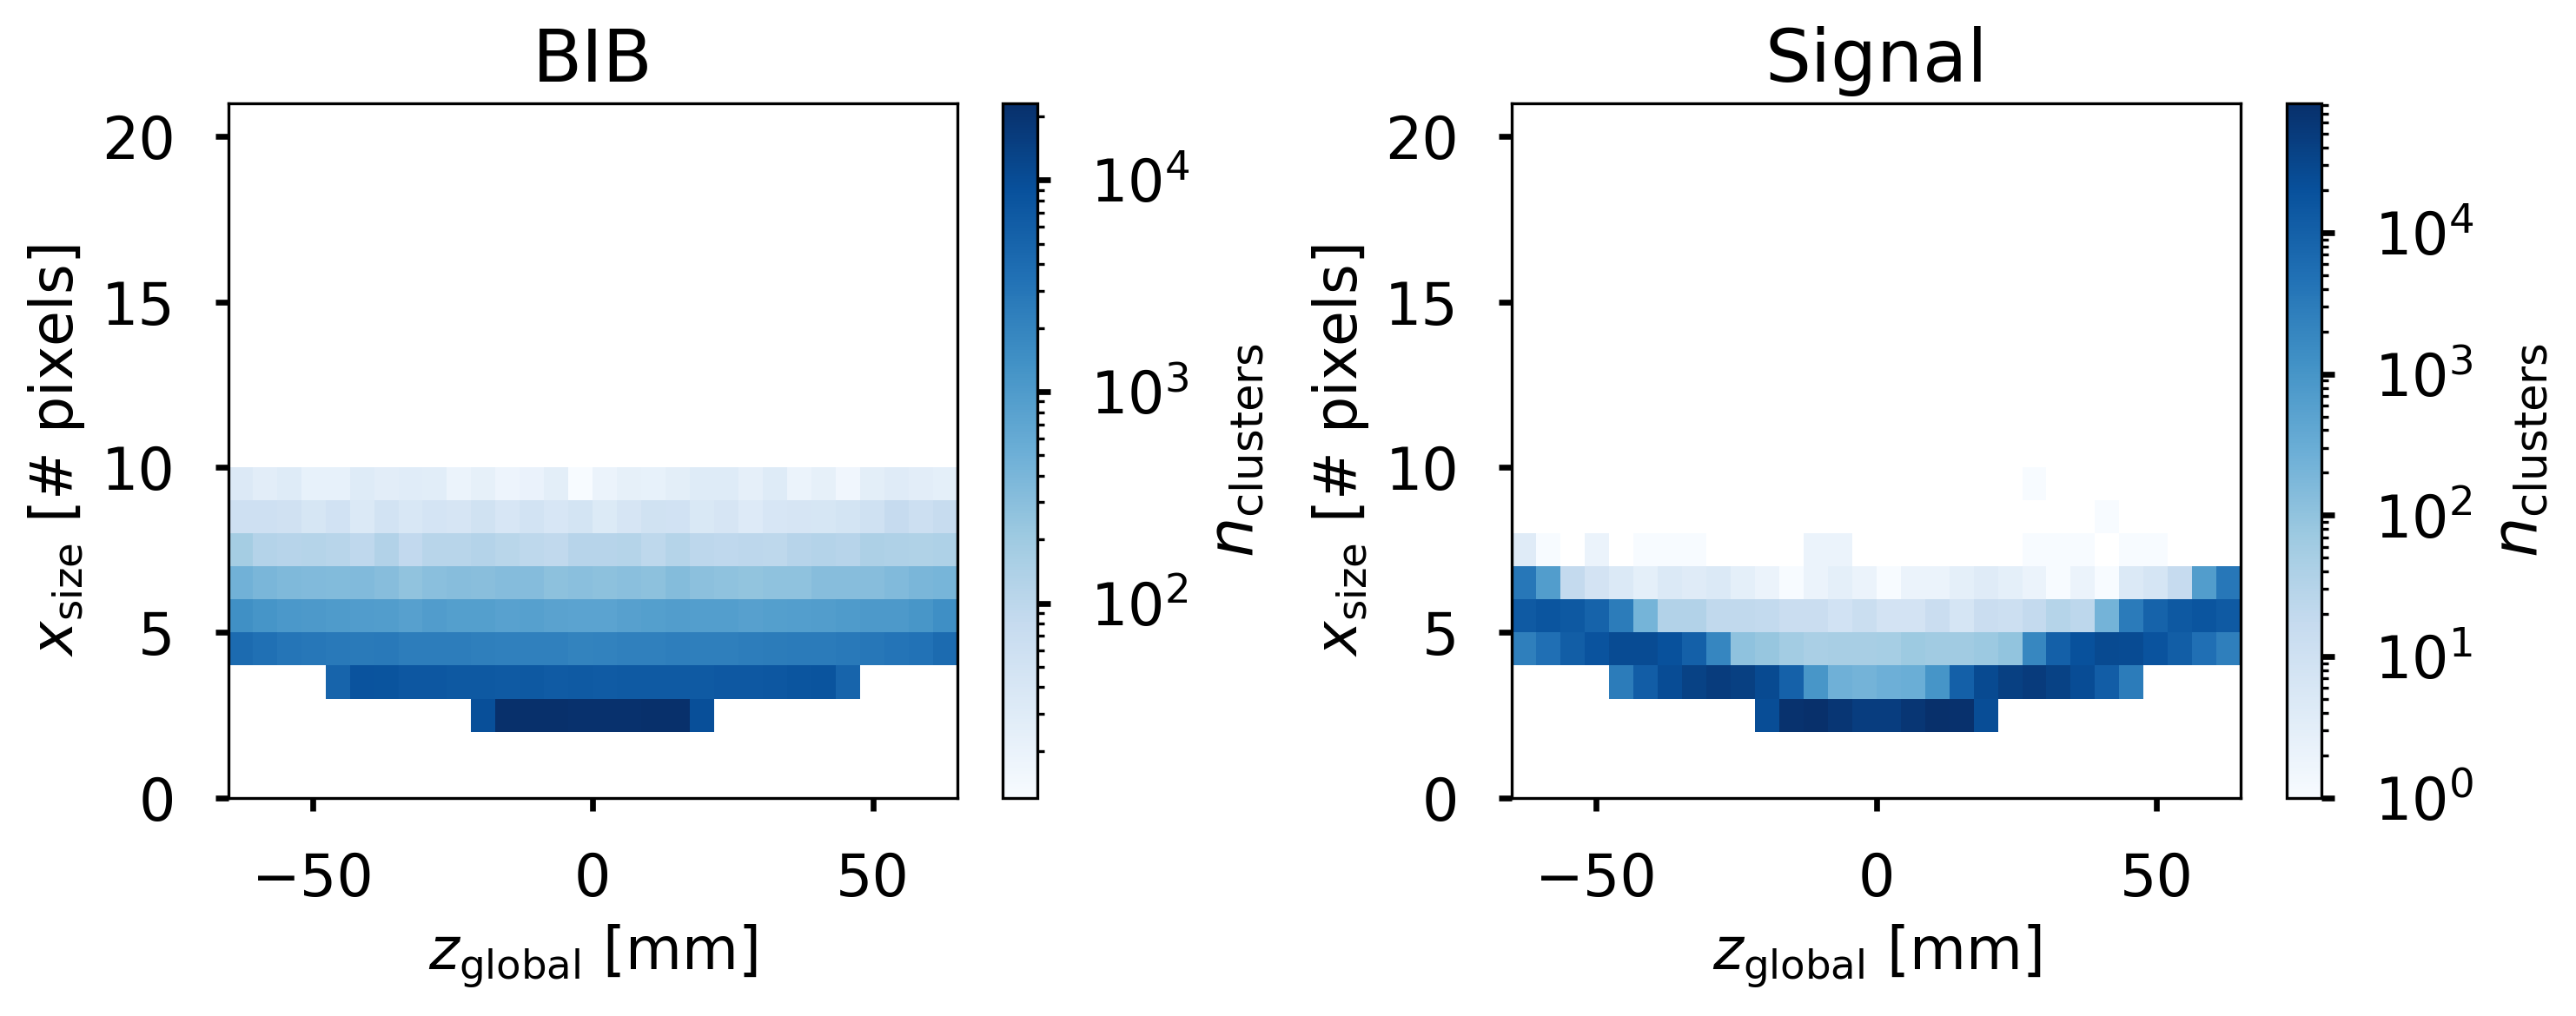

Plot saved as: ../datasetPlots/bib_signal_zglobal_vs_xsize_comparison.png
cut:  (nPix<10) and (xSize > `z-global`*0.0372422809955313 + 1.2884620749065145) and (xSize > `z-global`*-0.0372422809955313 + 1.2884620749065145)
number BIB clusters  478668 number of signal clusters  1345466
fraction of total bib  0.28893626679286466  fraction of total signal  0.7835747402432143
cut:  (nPix<10) and (xSize > `z-global`*0.0372422809955313 + -2.0) and (xSize > `z-global`*-0.0372422809955313 + -2.0)
number BIB clusters  1424631 number of signal clusters  1710524
fraction of total bib  0.8599437662375291  fraction of total signal  0.9961778290791323
cut:  (nPix<10) and (xSize > `z-global`*0.0372422809955313 + -1.9226844474508875) and (xSize > `z-global`*-0.0372422809955313 + -1.9226844474508875)
number BIB clusters  1424631 number of signal clusters  1710524
fraction of total bib  0.8599437662375291  fraction of total signal  0.9961778290791323
cut:  (nPix<10) and (xSize > `z-global`*0.0372422809955

In [175]:
def getCut(nPixL10:bool,slope:float,intercept:float,yVar="xSize",xVar="z-global"):
    cut = "(nPix<10) and " if nPixL10 else ""
    cut += f"({yVar} > `{xVar}`*{slope} + {intercept}) and ({yVar} > `{xVar}`*-{slope} + {intercept})"
    return cut
def getZCutStub(xMin,xMax,yMin,xVar,yVar):
    return f"(`{xVar}`<{xMax} and `{xVar}`>{xMin} and {yVar}>={yMin})"
def getZCuts(zEdges,xMaxes,nPixL10:bool):
    #zEdges[0] to zEdges[1] has the xMaxes[0] xMax
    assert len(zEdges) == len(xMaxes)+1
    nBins = len(xMaxes)
    cut = getZCutStub(zEdges[0],zEdges[1],xMaxes[0],"z-global","xSize")
    for idx in range(nBins-1):
        cut= cut+  " or " + getZCutStub(zEdges[idx+1],zEdges[idx+2],xMaxes[idx+1],"z-global","xSize")
    if nPixL10:
        cut = f"({cut}) and (nPix < 10)"
    return cut



allCutRes = []
print(getZCuts(z_edges,min_xsize,True))
# plotHaha(plotter.truthBib,plotter.truthSig,cut=getZCuts(z_edges,min_xsize-0.5),plotZgXs=True,plotNpEt=False)
allCutRes.append((plotHaha(plotter.truthBib,plotter.truthSig,cut=getZCuts(z_edges,min_xsize-0.5,True),plotZgXs=True,plotNpEt=False),"minxsizes per zglobal + nPix<10"))
allCutRes.append((plotHaha(plotter.truthBib,plotter.truthSig,cut=getZCuts(z_edges,min_xsize-0.5,False),plotZgXs=True,plotNpEt=False),"minxsizes per zglobal"))

for intercept in np.linspace(-2,b,5):
    allCutRes.append((plotHaha(plotter.truthBib,plotter.truthSig,cut=getCut(True,a,intercept),plotZgXs=True,plotNpEt=False),a,intercept))

for intercept in np.linspace(-2,b+0.5,50):
    allCutRes.append((plotHaha(plotter.truthBib,plotter.truthSig,cut=getCut(True,a,intercept),plotZgXs=False,plotNpEt=False),a,intercept))

for intercept in np.linspace(0.5,0.7,5):
    allCutRes.append((plotHaha(plotter.truthBib,plotter.truthSig,cut=getCut(True,a,intercept),plotZgXs=False,plotNpEt=False),a,intercept))


[((944674, 1710521, 0.5702294260244734, 0.9961760819341128), 'minxsizes per zglobal + nPix<10'), ((1143384, 1717083, 0.6901758723597415, 0.9999976704733075), 'minxsizes per zglobal'), ((1424631, 1710524, 0.8599437662375291, 0.9961778290791323), 0.0372422809955313, -2.0), ((1386926, 1710524, 0.8371840623521117, 0.9961778290791323), 0.0372422809955313, -1.1778844812733713), ((1262391, 1710524, 0.7620115461508001, 0.9961778290791323), 0.0372422809955313, -0.3557689625467426), ((861814, 1710159, 0.5202130074076936, 0.9959652597684334), 0.0372422809955313, 0.46634655617988585), ((478668, 1345466, 0.28893626679286466, 0.7835747402432143), 0.0372422809955313, 1.2884620749065145), ((1424631, 1710524, 0.8599437662375291, 0.9961778290791323), 0.0372422809955313, -2.0), ((1424631, 1710524, 0.8599437662375291, 0.9961778290791323), 0.0372422809955313, -1.9226844474508875), ((1424631, 1710524, 0.8599437662375291, 0.9961778290791323), 0.0372422809955313, -1.845368894901775), ((1424631, 1710524, 0.859

Text(0.5, 1.0, 'roc curve from shifting intercept of the filtering line')

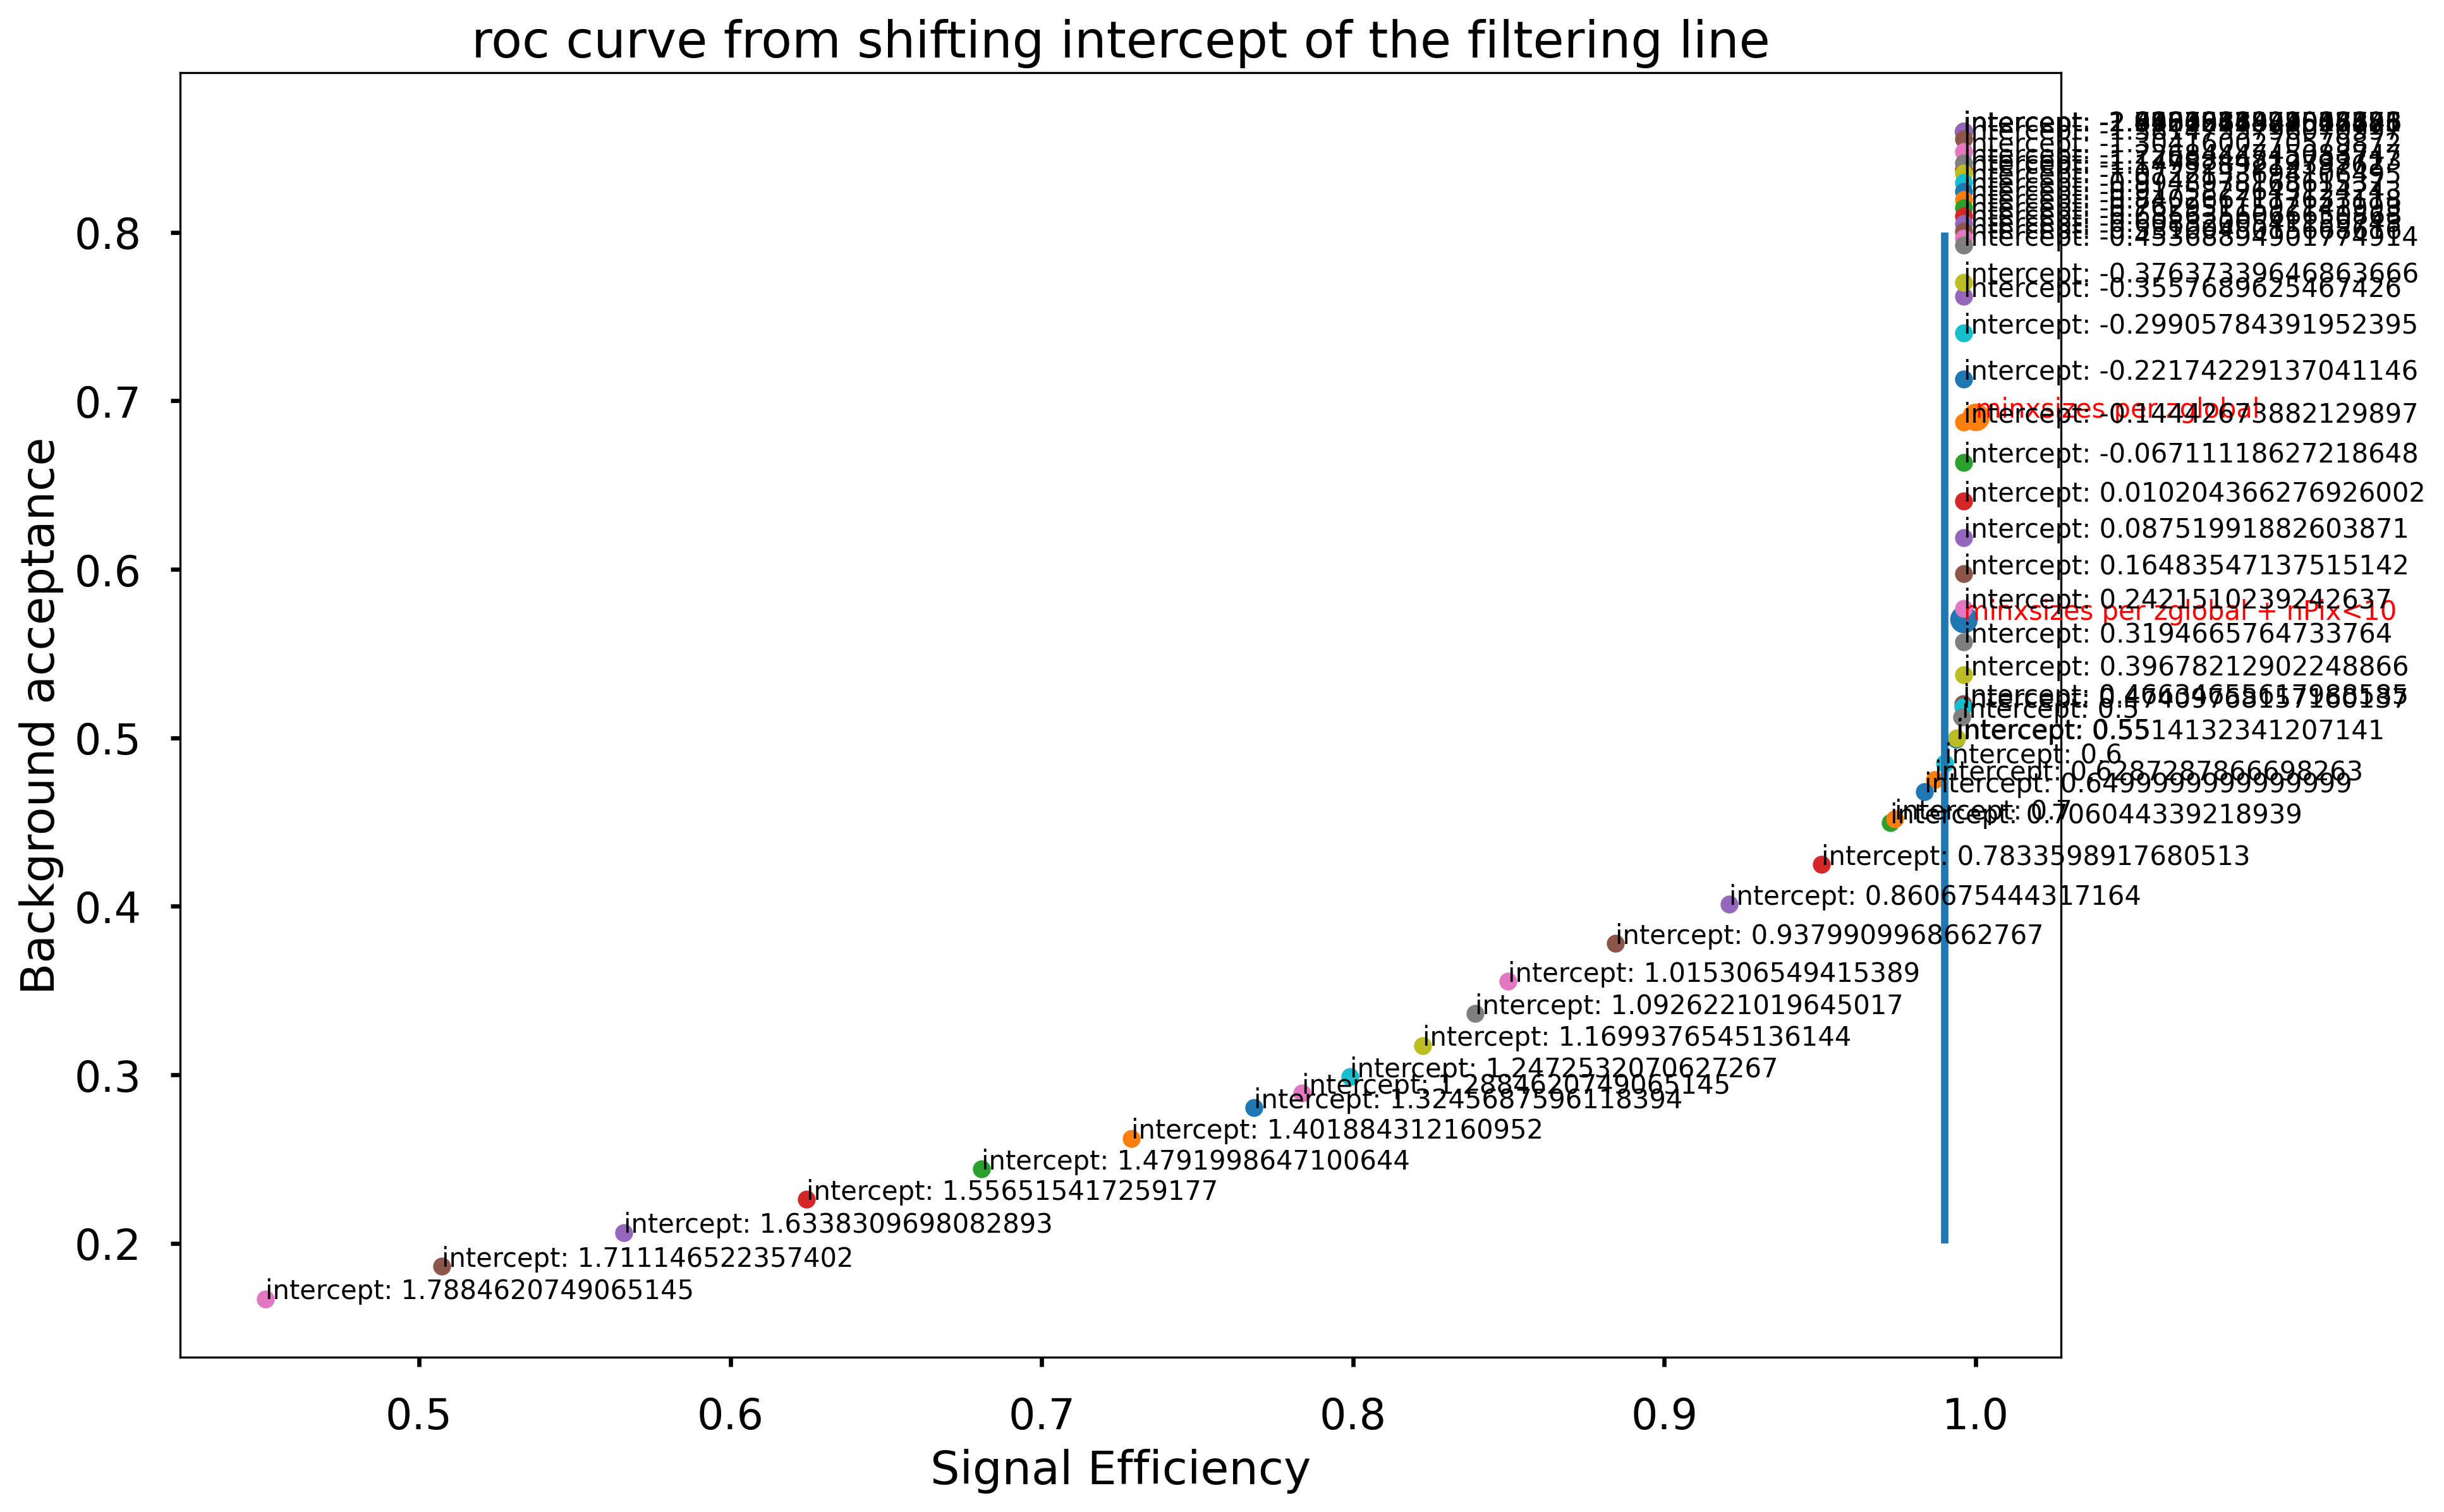

In [182]:
print(allCutRes)
for cut in allCutRes:
    if len(cut) < 3:
        plt.scatter(cut[0][3],cut[0][2],s=100)        
        plt.text(cut[0][3],cut[0][2],f"{cut[1]}",color="red")
    else:
        plt.scatter(cut[0][3],cut[0][2],s=40)
        plt.text(cut[0][3],cut[0][2],f"intercept: {cut[1:][1]}")

plt.ylabel("Background acceptance")
plt.xlabel("Signal Efficiency")
plt.vlines(0.99,0.2,0.8)
plt.title("roc curve from shifting intercept of the filtering line")